# Entendimiento de Datos — Proyecto RaSA

## Tarea 1: Modelado de Datos y ETL — MIAD

**Objetivo:** Explorar y evaluar la calidad de las fuentes de datos compartidas por RaSA
(Ente Regulador de Aseguradoras de Salud de los Alpes), como insumo para determinar la
viabilidad de los análisis solicitados en la matriz de temas analíticos.

**Fuentes analizadas:**
- F1. AreasDeServicio (`FuenteAreasDeServicio_Copia_E`)
- F2. TiposBeneficio (`FuenteTiposBeneficio_Copia_E`)
- F3. BeneficiosPlanes (`FuentePlanesBeneficio_Copia_E`)
- F4. CondicionesDePago (`FuenteCondicionesDePago_Copia_E`)

**Fuente de datos:** Base de datos `RaSaTransaccional`, servidor `157.253.236.120:8080`,
accedida vía PySpark JDBC.

In [59]:
from pyspark.sql import SparkSession

db_connection_string = 'jdbc:mysql://157.253.236.120:8080/RaSaTransaccional'
db_user = 'DB_202613_n_cantini'
db_psswd = '201630737'

PATH = './'

spark = SparkSession.builder \
    .appName("EntendimientoDatos_RaSA") \
    .config("spark.jars.packages", "mysql:mysql-connector-java:8.0.28") \
    .getOrCreate()

def leer_tabla(nombre_tabla):
    return spark.read.format("jdbc") \
        .option("url", db_connection_string) \
        .option("dbtable", nombre_tabla) \
        .option("user", db_user) \
        .option("password", db_psswd) \
        .option("driver", "com.mysql.cj.jdbc.Driver") \
        .load()

## 1. Configuración del entorno y conexión a la fuente

Se establece la conexión vía JDBC a la base de datos transaccional `RaSaTransaccional`.
El driver de MySQL se resuelve automáticamente mediante Maven (`spark.jars.packages`)
para evitar dependencias de archivos `.jar` locales.

In [60]:
df_areas = leer_tabla("FuenteAreasDeServicio_Copia_E")
df_tipos_beneficio = leer_tabla("FuenteTiposBeneficio_Copia_E")
df_planes_beneficio = leer_tabla("FuentePlanesBeneficio_Copia_E")
df_condiciones_pago = leer_tabla("FuenteCondicionesDePago_Copia_E")

# Verificación rápida
for nombre, df in [
    ("AreasDeServicio", df_areas),
    ("TiposBeneficio", df_tipos_beneficio),
    ("PlanesBeneficio", df_planes_beneficio),
    ("CondicionesDePago", df_condiciones_pago)
]:
    print(f"{nombre}: {df.count()} filas, {len(df.columns)} columnas")

AreasDeServicio: 188815 filas, 9 columnas


TiposBeneficio: 849 filas, 9 columnas


PlanesBeneficio: 36036 filas, 11 columnas
CondicionesDePago: 31 filas, 3 columnas


In [61]:
for nombre, df in [
    ("AreasDeServicio", df_areas),
    ("TiposBeneficio", df_tipos_beneficio),
    ("PlanesBeneficio", df_planes_beneficio),
    ("CondicionesDePago", df_condiciones_pago)
]:
    print(f"\n=== {nombre} ===")
    df.printSchema()
    df.show(5, truncate=False)


=== AreasDeServicio ===
root
 |-- IdAreaDeServicio_T: integer (nullable = true)
 |-- NombreAreaDeServicio: string (nullable = true)
 |-- IdGeografia_T: integer (nullable = true)
 |-- Condado: string (nullable = true)
 |-- Estado: string (nullable = true)
 |-- PoblacionAct: double (nullable = true)
 |-- Area: double (nullable = true)
 |-- Densidad: double (nullable = true)
 |-- Fecha: integer (nullable = true)



+------------------+---------------------------------------------+-------------+-----------------+----------+------------+-----+--------+-----+
|IdAreaDeServicio_T|NombreAreaDeServicio                         |IdGeografia_T|Condado          |Estado    |PoblacionAct|Area |Densidad|Fecha|
+------------------+---------------------------------------------+-------------+-----------------+----------+------------+-----+--------+-----+
|100622017         |New Jersey - Medical91661NJ2340003-0520174859|34005        |Burlington County|New Jersey|464269.0    |805.0|577.0   |2017 |
|101012018         |New Jersey - Medical91661NJ2340003-0520184611|34031        |Passaic County   |New Jersey|518117.0    |185.0|2801.0  |2018 |
|10132017          |BlueOptions16842FL0070128-032017260          |12031        |Duval County     |Florida   |999935.0    |774.0|1292.0  |2017 |
|101982018         |New Jersey - Medical91661NJ2340003-0520184591|34003        |Bergen County    |New Jersey|953819.0    |234.0|4076.0  

+-----------------+-----------------------------+------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|IdTipoBeneficio_T|Nombre                       |UnidadDelLimite         |EsEHB|EstaCubiertaPorSeguro|TieneLimiteCuantitativo|ExcluidoDelDesembolsoMaximoDentroDeLaRed|ExcluidoDelDesembolsoMaximoFueraDeLaRed|Fecha|
+-----------------+-----------------------------+------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|565              |Nutritional Counseling       |                        |No   |Yes                  |No                     |No                                      |Yes                                    |2017 |
|795              |Rehabilitative Speech Therapy|Days per Benefit Period |Yes  |Yes                  |Yes                    |No                

+-----------------+------------------+-------------------------+---------------------------+-----------------+-----------------+----------+-------------+-----------+-------------+--------------+
|IdTipoBeneficio_T|IdAreaDeServicio_T|IdCondicionDePagoCopago_T|IdCondicionDePagoCoseguro_T|IdNivelServicio_T|IdPlan_T         |Fecha     |IdProveedor_T|valorCopago|valorCoseguro|cantidadLimite|
+-----------------+------------------+-------------------------+---------------------------+-----------------+-----------------+----------+-------------+-----------+-------------+--------------+
|640              |10382017          |34                       |27                         |3                |16842FL0070128-03|2017-12-31|16842        |0          |50           |35            |
|225              |31512017          |238                      |45                         |2                |29418TX0140002-04|2017-12-31|29418        |0          |0            |NULL          |
|190              |662520

## 2. Fuente 1: AreasDeServicio

### 2.1 Perfilamiento de datos

La tabla `FuenteAreasDeServicio_Copia_E` contiene **188,815 filas** y **9 columnas**:

| Columna | Tipo de dato |
|---|---|
| IdAreaDeServicio_T | string |
| NombreAreaDeServicio | string |
| IdGeografia_T | integer |
| Condado | string |
| Estado | string |
| PoblacionAct | double |
| Area | double |
| Densidad | double |
| Fecha | integer |

El dato de negocio compartido por RaSA indica 5,409 áreas de servicio; en la fuente se
identificaron **5,410 valores distintos** de `IdAreaDeServicio_T`, consistente con lo
esperado.

In [62]:
# 1. ¿IdAreaDeServicio_T es realmente único por fila?
print("Filas totales:", df_areas.count())
print("IdAreaDeServicio_T distintos:", df_areas.select("IdAreaDeServicio_T").distinct().count())

# 2. ¿Cuántas combinaciones únicas de Condado+Estado hay? (¿se acerca a 5409?)
print("Condado+Estado distintos:", df_areas.select("Condado", "Estado").distinct().count())

# 3. ¿Cuántas filas hay por año?
df_areas.groupBy("Fecha").count().show()

# 4. Muestra de NombreAreaDeServicio para inspeccionar el patrón embebido
df_areas.select("NombreAreaDeServicio").distinct().show(20, truncate=False)

Filas totales: 188815


IdAreaDeServicio_T distintos: 5410


Condado+Estado distintos: 2282


+-----+-----+
|Fecha|count|
+-----+-----+
| 2018|83322|
| 1800| 6282|
| 2017|99211|
+-----+-----+



+--------------------------------------------------------------------------------+
|NombreAreaDeServicio                                                            |
+--------------------------------------------------------------------------------+
|Marketplace Extra HMO 122444PA0010047-0020186453                                |
|Indiana54192IN0010012-0220182342                                                |
|WV Statewide31274WV0480009-0120189543                                           |
|Ambetter of Magnolia90714MS0010005-0420173552                                   |
|Northeast Ohio99969OH0080069-0020185896                                         |
|South Dakota Service Area31195SD0080004-0120186816                              |
|Statewide (Arkansas)75293AR1230002-002017175                                    |
|Blue Preferred PPO87571OK0460011-0420176175                                     |
|Matthew Thornton Hlth Plan(Anthem BCBS)All96751NH0150022-0120174553             |
|Hea

In [63]:
df_condiciones_pago.groupBy("Tipo").count().show()
df_condiciones_pago.show(31, truncate=False)  # son pocas, verla completa

+-------------+-----+
|         Tipo|count|
+-------------+-----+
|     Copagado|    1|
|  Coseguridad|    1|
|       Copago|   19|
|SinTipoCopago|    1|
|          NaN|    2|
|     Coseguro|    7|
+-------------+-----+

+---------------------+--------------------------------+-------------+
|IdCondicionesDePago_T|Descripcion                     |Tipo         |
+---------------------+--------------------------------+-------------+
|187                  |Copay with deductible           |Copago       |
|204                  |Copay per Day                   |Copago       |
|45                   |Coinsurance                     |Coseguro     |
|85                   |Copay per Day before deductible |Copago       |
|18                   |No Charge after deductible      |Coseguro     |
|136                  |Copay per Stay with deductible  |Copago       |
|27                   |Coinsurance after deductible    |Coseguro     |
|238                  |Copay                           |Copago       

In [64]:
from pyspark.sql import functions as F

df_areas.groupBy("IdAreaDeServicio_T") \
    .agg(F.countDistinct("NombreAreaDeServicio").alias("nombres_distintos")) \
    .orderBy(F.desc("nombres_distintos")) \
    .show(10)

+------------------+-----------------+
|IdAreaDeServicio_T|nombres_distintos|
+------------------+-----------------+
|              NULL|             2697|
|          99002017|                1|
|         104422017|                1|
|           1482017|                1|
|          75512018|                1|
|          56982018|                1|
|          38822017|                1|
|         109842017|                1|
|          58472018|                1|
|          40312018|                1|
+------------------+-----------------+
only showing top 10 rows



In [65]:
from pyspark.sql import functions as F

# 1. Cuántas filas tienen IdAreaDeServicio_T nulo? (en número y %)
total = df_areas.count()
nulos = df_areas.filter(F.col("IdAreaDeServicio_T").isNull()).count()
print(f"Filas con ID nulo: {nulos} ({round(nulos/total*100, 2)}%)")

# 2. De las filas CON id (no nulas), cuánto se repite cada una?
df_areas.filter(F.col("IdAreaDeServicio_T").isNotNull()) \
    .groupBy("IdAreaDeServicio_T") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10)

Filas con ID nulo: 6288 (3.33%)


+------------------+-----+
|IdAreaDeServicio_T|count|
+------------------+-----+
|          92882017|  237|
|          92932017|  230|
|          92892017|  213|
|          92872017|  204|
|          92942017|  189|
|          92912017|  186|
|          76462018|  185|
|          76422017|  184|
|          33482017|  183|
|          92922017|  177|
+------------------+-----+
only showing top 10 rows



In [66]:
# Las filas con ID nulo son las mismas que tienen Fecha=1800?
df_areas.filter(F.col("IdAreaDeServicio_T").isNull()) \
    .groupBy("Fecha") \
    .count() \
    .show()

+-----+-----+
|Fecha|count|
+-----+-----+
| 2018| 2843|
| 2017| 3445|
+-----+-----+



In [67]:
# Para el ID que más se repite, son 237 condados DISTINTOS o hay condados repetidos?
df_areas.filter(F.col("IdAreaDeServicio_T") == "92882017") \
    .select("Condado", "Estado") \
    .distinct() \
    .count()

# Comparación: filas totales vs condados distintos para ese ID
df_areas.filter(F.col("IdAreaDeServicio_T") == "92882017") \
    .groupBy("Condado", "Estado") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10)

+----------------+-------+-----+
|         Condado| Estado|count|
+----------------+-------+-----+
| Tattnall County|Georgia|    4|
| Stephens County|Georgia|    4|
|Whitfield County|Georgia|    3|
| Brantley County|Georgia|    3|
| Haralson County|Georgia|    3|
|      Lee County|Georgia|    3|
| Gwinnett County|Georgia|    3|
|   Echols County|Georgia|    3|
|   Brooks County|Georgia|    3|
|   Jasper County|Georgia|    3|
+----------------+-------+-----+
only showing top 10 rows



### 2.2 Significado de una fila

Inicialmente se planteó la hipótesis de que cada fila representaba un área de servicio
única. Sin embargo, el análisis de valores distintos por `IdAreaDeServicio_T` mostró que
un mismo identificador puede repetirse hasta 237 veces. La investigación de esas
repeticiones —cruzando `IdAreaDeServicio_T` contra `Condado` y `Estado`— permitió
concluir que:

**Una fila representa la combinación entre un área de servicio (asociada a un plan o
proveedor específico) y un condado geográfico cubierto por dicha área.**

Esto explica por qué el conteo de filas (188,815) es muy superior al número de áreas de
servicio reportado por el negocio (5,409): cada área puede cubrir múltiples condados,
generando un registro por cada combinación área–condado.

In [68]:
from pyspark.sql import functions as F

# Total de filas vs. condados distintos para ese ID
total_filas = df_areas.filter(F.col("IdAreaDeServicio_T") == "92882017").count()
condados_distintos = df_areas.filter(F.col("IdAreaDeServicio_T") == "92882017") \
    .select("Condado", "Estado").distinct().count()

print(f"Filas totales: {total_filas}")
print(f"Condados distintos: {condados_distintos}")
print(f"Filas duplicadas (exceso): {total_filas - condados_distintos}")

# Y para tener una foto general (no solo de un ID), calculemos esto a nivel de TODA la tabla:
df_areas.groupBy("IdAreaDeServicio_T", "Condado", "Estado") \
    .count() \
    .filter(F.col("count") > 1) \
    .count()  # cuántas combinaciones (área+condado) tienen registros duplicados

Filas totales: 237
Condados distintos: 154
Filas duplicadas (exceso): 83


52598

In [69]:
# Las filas duplicadas son EXACTAMENTE iguales en todas las columnas, o difieren en algo (ej. PoblacionAct)?
df_areas.groupBy(df_areas.columns).count().filter(F.col("count") > 1).count()

43573

In [70]:
# Encontrar un ejemplo real de este caso: misma llave, pero valores distintos en otras columnas
df_areas.groupBy("IdAreaDeServicio_T", "Condado", "Estado") \
    .count() \
    .filter(F.col("count") > 1) \
    .join(df_areas, ["IdAreaDeServicio_T", "Condado", "Estado"]) \
    .orderBy("IdAreaDeServicio_T") \
    .show(6, truncate=False)

ERROR:root:KeyboardInterrupt while sending command.                             
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/socket.py", line 718, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
from pyspark.sql import functions as F

# Filas duplicadas en la llave, pero que NO son idénticas en todas las columnas
duplicados_llave = df_areas.groupBy("IdAreaDeServicio_T", "Condado", "Estado").count().filter(F.col("count") > 1)
duplicados_exactos = df_areas.groupBy(df_areas.columns).count().filter(F.col("count") > 1)

# Únicamente la llave de los duplicados que SÍ tienen inconsistencia
solo_inconsistentes = duplicados_llave.select("IdAreaDeServicio_T", "Condado", "Estado") \
    .subtract(duplicados_exactos.select("IdAreaDeServicio_T", "Condado", "Estado"))

# Filas completas de esos casos para ver el contraste
df_areas.join(solo_inconsistentes, ["IdAreaDeServicio_T", "Condado", "Estado"]) \
    .orderBy("IdAreaDeServicio_T", "Condado") \
    .show(10, truncate=False)

+------------------+----------------+--------+-----------------------------+-------------+------------+-----+--------+-----+
|IdAreaDeServicio_T|Condado         |Estado  |NombreAreaDeServicio         |IdGeografia_T|PoblacionAct|Area |Densidad|Fecha|
+------------------+----------------+--------+-----------------------------+-------------+------------+-----+--------+-----+
|42018             |Alexandria City |Virginia|NoVa10207VA0380001-0620189496|51510        |158309.0    |NULL |NULL    |2018 |
|42018             |Alexandria City |Virginia|NoVa10207VA0380001-0620189496|154530       |158309.0    |NULL |NULL    |2018 |
|62018             |Alexandria City |Virginia|NoVa10207VA0380001-0620188948|154530       |158309.0    |NULL |NULL    |2018 |
|62018             |Alexandria City |Virginia|NoVa10207VA0380001-0620188948|51510        |158309.0    |NULL |NULL    |2018 |
|62018             |Arlington County|Virginia|NoVa10207VA0380001-0620188948|51013        |232965.0    |26.0 |8960.0  |2018 |


In [ ]:
# Cuántas filas tienen poblaciones absurdas?
df_areas.filter(F.col("PoblacionAct") > 330000000).count()

# Estadística descriptiva rápida de PoblacionAct para ver el rango completo
df_areas.select("PoblacionAct").describe().show()

+-------+-------------------+
|summary|       PoblacionAct|
+-------+-------------------+
|  count|             188815|
|   mean|4.147959051463602E7|
| stddev|5.943835931334065E8|
|    min|               82.0|
|    max|         4.72803E10|
+-------+-------------------+



In [ ]:
outliers_poblacion = df_areas.filter(F.col("PoblacionAct") > 330000000).count()
print(f"Filas con PoblacionAct > 330M: {outliers_poblacion}")

Filas con PoblacionAct > 330M: 2918


### 2.3 Estadísticas descriptivas

La columna numérica `PoblacionAct` presenta un comportamiento anómalo:

| Estadístico | Valor |
|---|---|
| count | 188,815 |
| mean | 41,479,590 |
| stddev | 594,383,593 |
| min | 82 |
| max | 47,280,300,000 |

La desviación estándar es aproximadamente 14 veces mayor que la media, lo cual es
estadísticamente inconsistente con una distribución razonable de poblaciones por
condado, y anticipa la presencia de outliers extremos.

El histograma en escala logarítmica confirma visualmente este comportamiento: la
distribución de `PoblacionAct` presenta dos grupos claramente separados. El primero,
concentrado entre 10³ y 10⁶, es consistente con poblaciones reales de condados en
Estados Unidos. El segundo, ubicado entre 10⁸ y 10¹⁰, aparece completamente aislado
del grupo principal, sin continuidad ni transición gradual entre ambos. Esta
separación abrupta descarta que se trate de errores de captura aislados y sugiere
un problema sistemático de escala en el proceso de origen de los datos (por ejemplo,
un corrimiento de punto decimal o una transformación de unidades aplicada
incorrectamente a un subconjunto específico de registros).

Aplicando un umbral de negocio razonable (330 millones, población total de Estados
Unidos), se identificaron **2,918 filas (1.55% del total)** con valores de
`PoblacionAct` superiores a dicho umbral — ver hallazgo de Validez en 2.4.

La columna `Fecha` toma tres valores: 2017 (99,211 filas), 2018 (83,322 filas) y un
valor no válido, 1800 (6,282 filas) — ver hallazgo de Validez en 2.4.

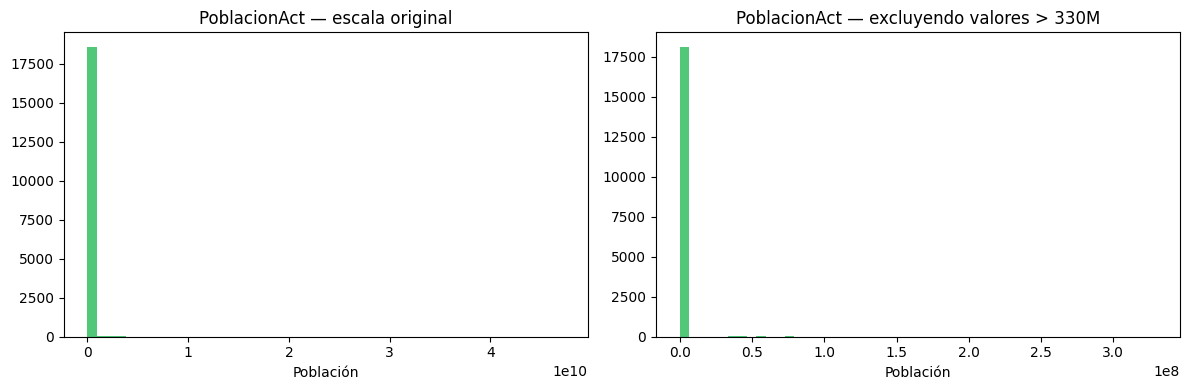

In [ ]:
import matplotlib.pyplot as plt

# Tomamos una muestra para graficar (no hace falta traer las 188,815 filas a pandas)
muestra_poblacion = df_areas.select("PoblacionAct").sample(0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica 1: distribución completa (se va a ver aplastada por los outliers)
axes[0].hist(muestra_poblacion["PoblacionAct"], bins=50, color="#50C878")
axes[0].set_title("PoblacionAct — escala original")
axes[0].set_xlabel("Población")

# Gráfica 2: mismo dato pero excluyendo outliers extremos, para ver la distribución real
sin_outliers = muestra_poblacion[muestra_poblacion["PoblacionAct"] <= 330000000]
axes[1].hist(sin_outliers["PoblacionAct"], bins=50, color="#50C878")
axes[1].set_title("PoblacionAct — excluyendo valores > 330M")
axes[1].set_xlabel("Población")

plt.tight_layout()
plt.show()

*Nota: la gráfica izquierda muestra la distribución completa de `PoblacionAct` en su
escala original; la altísima concentración de datos en una sola barra, junto con un
eje que se extiende hasta 4×10¹⁰, evidencia visualmente la presencia de valores
extremos. La gráfica derecha excluye los registros que superan los 330 millones
(población total de Estados Unidos, usada como umbral de negocio), pero el eje X
sigue llegando hasta 3×10⁸, lo que indica que existen valores anormalmente altos
incluso por debajo de ese umbral. Este comportamiento se investiga con mayor detalle
mediante una distribución en escala logarítmica a continuación.*

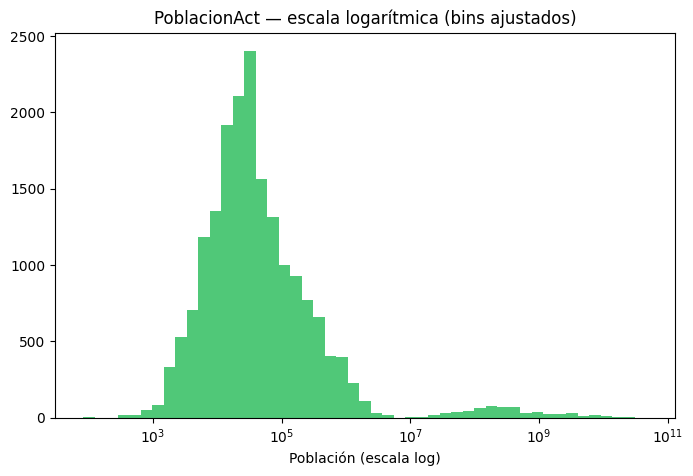

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))

# Bins espaciados logarítmicamente entre el mínimo y máximo real
bins_log = np.logspace(np.log10(muestra_poblacion["PoblacionAct"].min()),
                        np.log10(muestra_poblacion["PoblacionAct"].max()),
                        50)

ax.hist(muestra_poblacion["PoblacionAct"], bins=bins_log, color="#50C878")
ax.set_xscale("log")
ax.set_title("PoblacionAct — escala logarítmica (bins ajustados)")
ax.set_xlabel("Población (escala log)")
plt.show()

*Nota: al ajustar los bins del histograma a escala logarítmica, se revela que la
distribución de `PoblacionAct` está compuesta por dos grupos claramente separados.
El primero, concentrado entre 10³ y 10⁶, es consistente con poblaciones reales de
condados en Estados Unidos. El segundo, ubicado entre 10⁸ y 10¹⁰, aparece
completamente aislado del grupo principal, sin transición gradual entre ambos. Esta
separación abrupta —en lugar de una cola continua de valores altos— descarta que se
trate de errores de captura aislados y refuerza la hipótesis de un problema
sistemático de escala (por ejemplo, un corrimiento de punto decimal) aplicado a un
subconjunto específico de registros durante el proceso de origen de los datos.*

### 2.4 Análisis de calidad de datos

La exploración de `AreasDeServicio` evidenció cinco hallazgos de calidad, distribuidos
en las cuatro dimensiones evaluadas. La siguiente gráfica resume su magnitud relativa
sobre el total de la fuente (188,815 filas):

| # | Hallazgo | Dimensión | Magnitud |
|---|---|---|---|
| 1 | Fechas fuera de rango (año 1800) | Validez | 6,282 filas (3.33%) |
| 2 | `IdAreaDeServicio_T` nulo | Completitud | 6,288 filas (3.33%) |
| 3 | Duplicados exactos en la llave área+condado+estado | Unicidad | 43,573 combinaciones (23.08%) |
| 4 | `IdGeografia_T` inconsistente para una misma llave área+condado+estado | Consistencia | 9,025 combinaciones (4.78%) |
| 5 | `PoblacionAct` con valores fuera de rango físico posible (> 330M) | Validez | 2,918 filas (1.55%), máximo de 47.28 mil millones |

El hallazgo de mayor magnitud corresponde a la dimensión de **Unicidad**: más de una
quinta parte de las combinaciones de la llave natural (área de servicio + condado +
estado) presentan registros duplicados, lo cual compromete directamente la fiabilidad
de cualquier conteo de cobertura construido sobre esta fuente (Análisis 2 y 3 de la
matriz de temas analíticos) si no se aplica una deduplicación previa.

**Sobre los hallazgos 1 y 2:** si bien ambos afectan una cantidad similar de filas
(~6,280), se confirmó mediante cruce que no corresponden al mismo grupo de registros
— son dos problemas de calidad independientes, no una única causa raíz.

**Sobre el hallazgo 4:** se identificó un patrón sistemático en los valores en
conflicto de `IdGeografia_T`: uno de los dos valores corresponde al otro con un prefijo
adicional "15" (ej. `13` vs. `153039`), lo que sugiere un error de carga o
concatenación en el proceso de origen, más que un dato aleatoriamente incorrecto.

**Sobre el hallazgo 5:** el histograma en escala logarítmica (sección 2.3) mostró que
los valores extremos de `PoblacionAct` forman un grupo aislado y no una cola continua
de la distribución, lo cual refuerza la hipótesis de un error sistemático de escala
en el proceso de origen, más que errores de captura aislados.

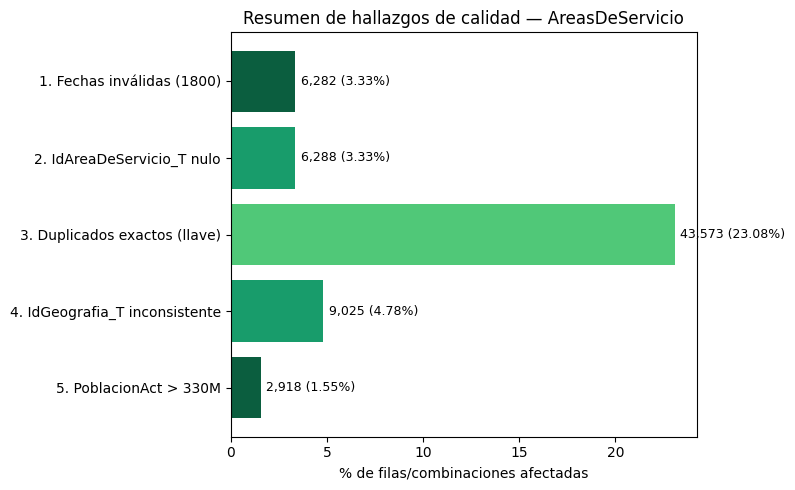

In [ ]:
hallazgos = [
    "1. Fechas inválidas (1800)",
    "2. IdAreaDeServicio_T nulo",
    "3. Duplicados exactos (llave)",
    "4. IdGeografia_T inconsistente",
    "5. PoblacionAct > 330M"
]
magnitudes = [6282, 6288, 43573, 9025, 2918]
porcentajes = [round(m / 188815 * 100, 2) for m in magnitudes]

colores = ["#0b5e3f", "#189c6b", "#50C878", "#189c6b", "#0b5e3f"]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(hallazgos, porcentajes, color=colores)

ax.set_xlabel("% de filas/combinaciones afectadas")
ax.set_title("Resumen de hallazgos de calidad — AreasDeServicio")
ax.invert_yaxis()  # para que el hallazgo 1 quede arriba

# Etiquetas con el número absoluto al final de cada barra
for barra, magnitud, pct in zip(barras, magnitudes, porcentajes):
    ax.text(barra.get_width() + 0.3, barra.get_y() + barra.get_height()/2,
             f"{magnitud:,} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

*Nota: los hallazgos 1, 2 y 5 están calculados sobre el total de filas de la fuente
(188,815). El hallazgo 3 (duplicados exactos) y el hallazgo 4 (`IdGeografia_T`
inconsistente) se expresan sobre el total de combinaciones únicas de la llave
área+condado+estado, no sobre filas individuales, ya que ambos corresponden a
problemas detectados a nivel de esa combinación. El hallazgo 3 representa la porción
de mayor magnitud relativa de esta fuente: más de una quinta parte de las
combinaciones de la llave natural presentan registros duplicados, lo cual debe
tratarse mediante deduplicación antes de calcular indicadores de cobertura de áreas
de servicio (Análisis 2 y 3 de la matriz de temas analíticos).*

## 3. Fuente 2: TiposBeneficio

### 3.1 Perfilamiento de datos

La tabla `FuenteTiposBeneficio_Copia_E` contiene **849 filas** y **9 columnas**:

| Columna | Tipo de dato |
|---|---|
| IdTipoBeneficio_T | integer |
| Nombre | string |
| UnidadDelLimite | string |
| EsEHB | string |
| EstaCubiertaPorSeguro | string |
| TieneLimiteCuantitativo | string |
| ExcluidoDelDesembolsoMaximoDentroDeLaRed | string |
| ExcluidoDelDesembolsoMaximoFueraDeLaRed | string |
| Fecha | integer |

El dato de negocio compartido por RaSA indica 170 tipos de beneficio. Dado que la
fuente cubre múltiples años (2017-2019), es esperable que el conteo total de filas
(849) sea superior a 170 si un mismo tipo de beneficio se repite por año — hipótesis
a confirmar en la sección de significado de una fila.

In [ ]:
from pyspark.sql import functions as F

# 1. Conteo de nulos por columna
df_tipos_beneficio.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_tipos_beneficio.decorate if False
]) if False else None  # placeholder, usamos la versión de abajo

df_tipos_beneficio.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c + "_nulos") for c in df_tipos_beneficio.columns
]).show()

# 2. Cantidad de valores distintos por columna (para detectar categorías raras)
for c in df_tipos_beneficio.columns:
    print(c, "->", df_tipos_beneficio.select(c).distinct().count(), "valores distintos")

+-----------------------+------------+---------------------+-----------+---------------------------+-----------------------------+----------------------------------------------+---------------------------------------------+-----------+
|IdTipoBeneficio_T_nulos|Nombre_nulos|UnidadDelLimite_nulos|EsEHB_nulos|EstaCubiertaPorSeguro_nulos|TieneLimiteCuantitativo_nulos|ExcluidoDelDesembolsoMaximoDentroDeLaRed_nulos|ExcluidoDelDesembolsoMaximoFueraDeLaRed_nulos|Fecha_nulos|
+-----------------------+------------+---------------------+-----------+---------------------------+-----------------------------+----------------------------------------------+---------------------------------------------+-----------+
|                      0|           0|                    0|          0|                          0|                            0|                                             0|                                            0|          0|
+-----------------------+------------+------------------

Nombre -> 178 valores distintos
UnidadDelLimite -> 63 valores distintos
EsEHB -> 3 valores distintos


EstaCubiertaPorSeguro -> 3 valores distintos
TieneLimiteCuantitativo -> 4 valores distintos
ExcluidoDelDesembolsoMaximoDentroDeLaRed -> 3 valores distintos


ExcluidoDelDesembolsoMaximoFueraDeLaRed -> 2 valores distintos
Fecha -> 2 valores distintos


In [ ]:
mismatch_id = df_tipos_beneficio.groupBy("IdTipoBeneficio_T") \
    .agg(F.countDistinct("Nombre").alias("nombres_distintos")) \
    .filter(F.col("nombres_distintos") > 1).count()

mismatch_nombre = df_tipos_beneficio.groupBy("Nombre") \
    .agg(F.countDistinct("IdTipoBeneficio_T").alias("ids_distintos")) \
    .filter(F.col("ids_distintos") > 1).count()

print(f"IDs con más de un nombre distinto: {mismatch_id}")
print(f"Nombres con más de un ID distinto: {mismatch_nombre}")

IDs con más de un nombre distinto: 0
Nombres con más de un ID distinto: 0


In [ ]:
# IdTipoBeneficio_T + Fecha es único en TiposBeneficio?
duplicados_tipo_fecha = df_tipos_beneficio.groupBy("IdTipoBeneficio_T", "Fecha") \
    .count().filter(F.col("count") > 1)

print(f"Combinaciones ID+Año con más de 1 fila: {duplicados_tipo_fecha.count()}")
duplicados_tipo_fecha.select("count").summary("min", "25%", "50%", "75%", "max").show()

# Agregar UnidadDelLimite resuelve la ambigüedad?
duplicados_con_unidad = df_tipos_beneficio.groupBy("IdTipoBeneficio_T", "Fecha", "UnidadDelLimite") \
    .count().filter(F.col("count") > 1).count()
print(f"Combinaciones ID+Año+UnidadDelLimite con más de 1 fila: {duplicados_con_unidad}")

# Ejemplo concreto para evidenciar que no son duplicados exactos
ejemplo_id = duplicados_tipo_fecha.orderBy(F.desc("count")).first()["IdTipoBeneficio_T"]
df_tipos_beneficio.filter(F.col("IdTipoBeneficio_T") == ejemplo_id).show(20, truncate=False)

Combinaciones ID+Año con más de 1 fila: 161
+-------+-----+
|summary|count|
+-------+-----+
|    min|    2|
|    25%|    2|
|    50%|    3|
|    75%|    6|
|    max|   25|
+-------+-----+



Combinaciones ID+Año+UnidadDelLimite con más de 1 fila: 212


+-----------------+------------------------+---------------------------------------------------------------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|IdTipoBeneficio_T|Nombre                  |UnidadDelLimite                                                                  |EsEHB|EstaCubiertaPorSeguro|TieneLimiteCuantitativo|ExcluidoDelDesembolsoMaximoDentroDeLaRed|ExcluidoDelDesembolsoMaximoFueraDeLaRed|Fecha|
+-----------------+------------------------+---------------------------------------------------------------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|865              |Skilled Nursing Facility|                                                                                 |Yes  |No                   |No                     |No                      

### 3.2 Significado de una fila

Se planteó inicialmente la hipótesis de que cada fila representaba un tipo de
beneficio específico reportado para un año dado. Sin embargo, un análisis adicional
—motivado por inconsistencias detectadas al intentar integrar esta fuente con
`PlanesBeneficio` (ver sección 6)— reveló que la combinación `IdTipoBeneficio_T` +
`Fecha` **no es única**: existen 161 combinaciones con múltiples filas (entre 2 y 25,
mediana de 3), y estas filas presentan valores genuinamente distintos en columnas como
`UnidadDelLimite`, `EsEHB`, `EstaCubiertaPorSeguro` y `TieneLimiteCuantitativo` — no se
trata de duplicados exactos.

Se evaluó si agregar `UnidadDelLimite` a la combinación de llave resolvía la
ambigüedad, pero el problema persiste (212 combinaciones con múltiples filas al
agregar esta columna). **No fue posible identificar, con las columnas disponibles en
esta fuente, una combinación que garantice unicidad por tipo de beneficio y año.**

La hipótesis más plausible es que cada fila representa una configuración de tipo de
beneficio **según es reportada por un plan o proveedor específico**, y que la llave
completa requeriría un identificador adicional (por ejemplo, `IdPlan_T` o
`IdProveedor_T`) que no está presente en esta fuente. Esta limitación se documenta
como una duda formal para RaSA (sección de conclusiones) y condiciona la forma en que
esta fuente puede integrarse con `PlanesBeneficio` (ver sección 6).

In [ ]:
for c in ["Fecha", "EsEHB", "EstaCubiertaPorSeguro", "TieneLimiteCuantitativo",
          "ExcluidoDelDesembolsoMaximoDentroDeLaRed", "ExcluidoDelDesembolsoMaximoFueraDeLaRed"]:
    print(f"\n=== {c} ===")
    df_tipos_beneficio.groupBy(c).count().orderBy(F.desc("count")).show()


=== Fecha ===
+-----+-----+
|Fecha|count|
+-----+-----+
| 2017|  672|
| 2018|  177|
+-----+-----+


=== EsEHB ===
+-----+-----+
|EsEHB|count|
+-----+-----+
|  Yes|  430|
|   No|  399|
| True|   20|
+-----+-----+


=== EstaCubiertaPorSeguro ===
+---------------------+-----+
|EstaCubiertaPorSeguro|count|
+---------------------+-----+
|                  Yes|  743|
|                   No|   98|
|                False|    8|
+---------------------+-----+


=== TieneLimiteCuantitativo ===


+-----------------------+-----+
|TieneLimiteCuantitativo|count|
+-----------------------+-----+
|                     No|  542|
|                    Yes|  271|
|                   Nein|   24|
|                     Si|   12|
+-----------------------+-----+


=== ExcluidoDelDesembolsoMaximoDentroDeLaRed ===


+----------------------------------------+-----+
|ExcluidoDelDesembolsoMaximoDentroDeLaRed|count|
+----------------------------------------+-----+
|                                      No|  787|
|                                     Yes|   60|
|                           Algunas veces|    2|
+----------------------------------------+-----+


=== ExcluidoDelDesembolsoMaximoFueraDeLaRed ===
+---------------------------------------+-----+
|ExcluidoDelDesembolsoMaximoFueraDeLaRed|count|
+---------------------------------------+-----+
|                                     No|  516|
|                                    Yes|  333|
+---------------------------------------+-----+



In [ ]:
from pyspark.sql import functions as F

total = df_tipos_beneficio.count()

# Moda (valor más frecuente) y % que representa, por columna categórica
columnas_categoricas = ["UnidadDelLimite", "EsEHB", "EstaCubiertaPorSeguro",
                         "TieneLimiteCuantitativo", "ExcluidoDelDesembolsoMaximoDentroDeLaRed",
                         "ExcluidoDelDesembolsoMaximoFueraDeLaRed"]

for c in columnas_categoricas:
    moda = df_tipos_beneficio.groupBy(c).count().orderBy(F.desc("count")).first()
    print(f"{c}: valor más frecuente = '{moda[c]}' ({moda['count']} filas, {round(moda['count']/total*100,2)}%)")

# Distribución completa de UnidadDelLimite (la columna con mayor cardinalidad, 63 valores)
df_tipos_beneficio.groupBy("UnidadDelLimite").count().orderBy(F.desc("count")).show(15, truncate=False)

# Distribución de Fecha (formalizada aquí como estadística descriptiva de la fuente)
df_tipos_beneficio.groupBy("Fecha").count().orderBy("Fecha").show()

UnidadDelLimite: valor más frecuente = '' (559 filas, 65.84%)


EsEHB: valor más frecuente = 'Yes' (430 filas, 50.65%)


EstaCubiertaPorSeguro: valor más frecuente = 'Yes' (743 filas, 87.51%)


TieneLimiteCuantitativo: valor más frecuente = 'No' (542 filas, 63.84%)


ExcluidoDelDesembolsoMaximoDentroDeLaRed: valor más frecuente = 'No' (787 filas, 92.7%)
ExcluidoDelDesembolsoMaximoFueraDeLaRed: valor más frecuente = 'No' (516 filas, 60.78%)
+---------------------------------------------------------------------------------+-----+
|UnidadDelLimite                                                                  |count|
+---------------------------------------------------------------------------------+-----+
|                                                                                 |559  |
|Visit(s) per Year                                                                |64   |
|Visit(s) per Benefit Period                                                      |31   |
|Days per Year                                                                    |14   |
|Days per Benefit Period                                                          |13   |
|Visit(s) per YearVisit(s) per YearVisit(s) per Year                              |11   |
|Item(s) per Y

### 3.3 Estadísticas descriptivas

Dado que la fuente es mayormente categórica, las estadísticas descriptivas se centran
en la moda (valor más frecuente) y su representatividad por columna:

| Columna | Valor más frecuente | Frecuencia |
|---|---|---|
| `UnidadDelLimite` | (vacío) | 559 filas (65.84%) |
| `EsEHB` | Yes | 430 filas (50.65%) |
| `EstaCubiertaPorSeguro` | Yes | 743 filas (87.51%) |
| `TieneLimiteCuantitativo` | No | 542 filas (63.84%) |
| `ExcluidoDelDesembolsoMaximoDentroDeLaRed` | No | 787 filas (92.70%) |
| `ExcluidoDelDesembolsoMaximoFueraDeLaRed` | No | 516 filas (60.78%) |

El porcentaje de valores vacíos en `UnidadDelLimite` (65.84%) es consistente con el
porcentaje de tipos de beneficio sin límite cuantitativo (`TieneLimiteCuantitativo =
No`, 63.84%), lo cual sugiere una relación lógica coherente entre ambas columnas: un
beneficio sin límite cuantitativo no requiere una unidad de medida para dicho límite.

El detalle de `UnidadDelLimite` (63 valores distintos) reveló dos hallazgos
adicionales de calidad, no visibles a nivel de conteos generales:

- **Error de concatenación:** valores como `"Visit(s) per YearVisit(s) per
  YearVisit(s) per Year"` (11 filas) y `"Visit(s) per Benefit PeriodVisit(s) per
  Benefit PeriodVisit(s) per Benefit Period"` (7 filas) corresponden al mismo texto
  repetido tres veces de forma consecutiva, indicando un error de concatenación en el
  proceso de carga de datos.
- **Inconsistencia de capitalización:** `"Visit(s) per Year"` (64 filas) y
  `"Visit(s) per year"` (6 filas) representan el mismo concepto con distinta
  capitalización, fragmentando lo que debería ser una única categoría.

Estos hallazgos se consolidan en la sección de calidad de datos a continuación.

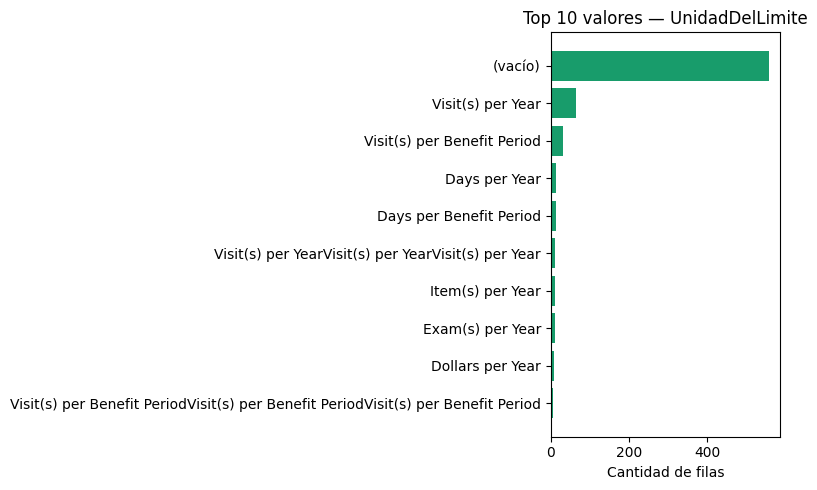

In [ ]:
import matplotlib.pyplot as plt

top_unidades = df_tipos_beneficio.groupBy("UnidadDelLimite").count() \
    .orderBy(F.desc("count")).limit(10).toPandas()

# Reemplazamos el vacío por una etiqueta legible
top_unidades["UnidadDelLimite"] = top_unidades["UnidadDelLimite"].replace("", "(vacío)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_unidades["UnidadDelLimite"], top_unidades["count"], color="#189c6b")
ax.set_xlabel("Cantidad de filas")
ax.set_title("Top 10 valores — UnidadDelLimite")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

*Nota: el top 10 de `UnidadDelLimite` muestra el valor vacío como el más frecuente
(consistente con la ausencia de límite cuantitativo en la mayoría de los tipos de
beneficio), seguido de "Visit(s) per Year" como la unidad más común. Se observa que
variantes de esta misma categoría —debido a errores de concatenación y de
capitalización— aparecen como entradas separadas en el top 10, fragmentando lo que
debería ser una única categoría y subestimando su frecuencia real.*

### 3.4 Análisis de calidad de datos

**Completitud:** la fuente `TiposBeneficio` no presenta valores nulos en ninguna de
sus 9 columnas — a diferencia de `AreasDeServicio`, esta dimensión no arroja hallazgos
en esta fuente.

**Consistencia:** de las cinco columnas con naturaleza binaria (Yes/No) presentes en
la fuente, cuatro presentan valores adicionales a los dos esperados, evidenciando falta
de estandarización en el catálogo de origen:

| Columna | Valores encontrados | Valores fuera de estándar |
|---|---|---|
| `EsEHB` | Yes (430), No (399), True (20) | `True` — mezcla de tipo booleano con texto |
| `EstaCubiertaPorSeguro` | Yes (743), No (98), False (8) | `False` — mezcla de tipo booleano con texto |
| `TieneLimiteCuantitativo` | No (542), Yes (271), Nein (24), Si (12) | `Nein` (alemán), `Si` (español) — mezcla de idiomas |
| `ExcluidoDelDesembolsoMaximoDentroDeLaRed` | No (787), Yes (60), Algunas veces (2) | `Algunas veces` — introduce una tercera categoría real, no solo un problema de formato |
| `ExcluidoDelDesembolsoMaximoFueraDeLaRed` | No (516), Yes (333) | Ninguno — única columna binaria sin inconsistencias |

El caso de `TieneLimiteCuantitativo` es el más severo: mezcla inglés, alemán y español
para representar el mismo concepto binario, lo que indica que los datos provienen de
múltiples fuentes o sistemas de captura sin un catálogo estandarizado. El caso de
`ExcluidoDelDesembolsoMaximoDentroDeLaRed` es distinto en naturaleza: el valor
`Algunas veces` no es una variante de "Yes"/"No", sino una posible tercera categoría
legítima capturada de forma inconsistente — se incluye en la lista de dudas para RaSA
en la sección de conclusiones.

**Validez / cobertura temporal:** el enunciado del proyecto indica que las fuentes
`AreasDeServicio` y `TiposBeneficio` comparten información de los años 2017 a 2019. Sin
embargo, `TiposBeneficio` únicamente contiene registros de 2017 (672 filas) y 2018
(177 filas) — el año 2019 no está presente en la fuente. Esta discrepancia se incluye
en la lista de dudas para RaSA, ya que puede tratarse de un año pendiente de carga o de
un ajuste al alcance temporal original del proyecto.

**Unicidad:** la combinación `IdTipoBeneficio_T` + `Fecha`, que se esperaría fuera
única dado el significado inicialmente planteado para una fila, presenta 161
combinaciones con más de un registro (entre 2 y 25 filas por combinación). Estos no
son duplicados exactos: los registros dentro de una misma combinación difieren en
columnas como `UnidadDelLimite`, `EsEHB` y `TieneLimiteCuantitativo`, lo que impide
tratarlos como redundantes y sugiere que la fuente carece de una columna necesaria
para expresar su grano real (ver sección 3.2).

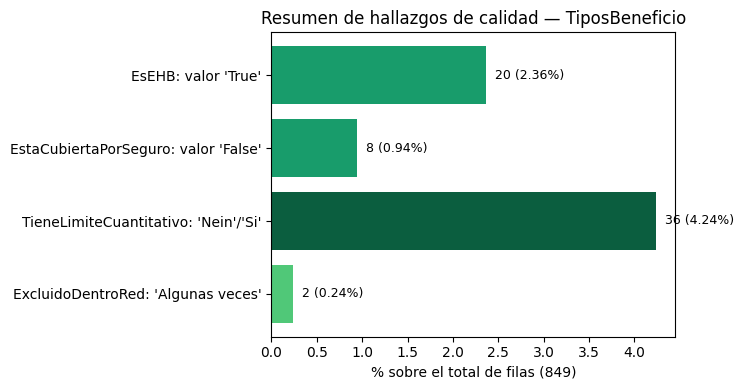

In [ ]:
hallazgos_tipos = [
    "EsEHB: valor 'True'",
    "EstaCubiertaPorSeguro: valor 'False'",
    "TieneLimiteCuantitativo: 'Nein'/'Si'",
    "ExcluidoDentroRed: 'Algunas veces'",
    "Cobertura temporal: año 2019 ausente"
]

total_filas = 849
magnitudes = [20, 8, 36, 2, 0]  # el último no aplica como conteo de filas, se trata aparte
porcentajes = [round(m / total_filas * 100, 2) for m in magnitudes[:4]]

colores = ["#189c6b", "#189c6b", "#0b5e3f", "#50C878"]

fig, ax = plt.subplots(figsize=(7.5, 4))
barras = ax.barh(hallazgos_tipos[:4], porcentajes, color=colores)

ax.set_xlabel("% sobre el total de filas (849)")
ax.set_title("Resumen de hallazgos de calidad — TiposBeneficio")
ax.invert_yaxis()

for barra, magnitud, pct in zip(barras, magnitudes[:4], porcentajes):
    ax.text(barra.get_width() + 0.1, barra.get_y() + barra.get_height()/2,
             f"{magnitud} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

*Nota: los porcentajes están calculados sobre el total de filas de la fuente (849).
El hallazgo de cobertura temporal (ausencia del año 2019) no se expresa como
porcentaje de filas, ya que es un problema de completitud a nivel de negocio —
un año completo faltante en la fuente — y no de valores individuales dentro de un
registro; se documenta como hallazgo cualitativo en la sección 3.4 y en la lista de
dudas para RaSA. El caso `ExcluidoDelDesembolsoMaximoDentroDeLaRed = "Algunas veces"`,
aunque representa solo 2 filas (0.24%), se destaca por introducir una tercera
categoría conceptual y no solo una variante de formato, a diferencia de los demás
casos de esta tabla.*

## 4. Fuente 3: BeneficiosPlanes

### 4.1 Perfilamiento de datos

La tabla `FuentePlanesBeneficio_Copia_E` contiene **36,036 filas** y **11 columnas**:

| Columna | Tipo de dato |
|---|---|
| IdTipoBeneficio_T | long |
| IdAreaDeServicio_T | long |
| IdCondicionDePagoCopago_T | integer |
| IdCondicionDePagoCoseguro_T | integer |
| IdNivelServicio_T | integer |
| IdPlan_T | string |
| Fecha | string |
| IdProveedor_T | integer |
| valorCopago | integer |
| valorCoseguro | integer |
| cantidadLimite | integer |

Esta fuente corresponde a la tabla de hechos central del modelo: relaciona tipos de
beneficio, áreas de servicio, condiciones de pago (copago y coseguro), y planes
ofrecidos por proveedor, junto con las métricas de valor de copago, coseguro y
cantidad límite.

El negocio reportó 301 planes distintos para 2017 y 422 para 2018 (723 en total).

In [ ]:
from pyspark.sql import functions as F

# Nulos por columna
df_planes_beneficio.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c + "_nulos") for c in df_planes_beneficio.columns
]).show()

# Valores distintos por columna (para dimensionar cardinalidad)
for c in df_planes_beneficio.columns:
    print(c, "->", df_planes_beneficio.select(c).distinct().count(), "valores distintos")

+-----------------------+------------------------+-------------------------------+---------------------------------+-----------------------+--------------+-----------+-------------------+-----------------+-------------------+--------------------+
|IdTipoBeneficio_T_nulos|IdAreaDeServicio_T_nulos|IdCondicionDePagoCopago_T_nulos|IdCondicionDePagoCoseguro_T_nulos|IdNivelServicio_T_nulos|IdPlan_T_nulos|Fecha_nulos|IdProveedor_T_nulos|valorCopago_nulos|valorCoseguro_nulos|cantidadLimite_nulos|
+-----------------------+------------------------+-------------------------------+---------------------------------+-----------------------+--------------+-----------+-------------------+-----------------+-------------------+--------------------+
|                   2086|                    2041|                              0|                                0|                      0|             0|          0|                  0|                0|                  0|               30571|
+-----------

IdTipoBeneficio_T -> 286 valores distintos


IdAreaDeServicio_T -> 6497 valores distintos


IdCondicionDePagoCopago_T -> 14 valores distintos


IdCondicionDePagoCoseguro_T -> 5 valores distintos


...

Fecha -> 5 valores distintos


IdProveedor_T -> 125 valores distintos


valorCopago -> 49 valores distintos


valorCoseguro -> 25 valores distintos


cantidadLimite -> 42 valores distintos


In [ ]:
# 1. Cuántos IdTipoBeneficio_T en PlanesBeneficio NO existen en TiposBeneficio?
huerfanos_tipo = df_planes_beneficio.select("IdTipoBeneficio_T").distinct() \
    .join(df_tipos_beneficio.select("IdTipoBeneficio_T").distinct(),
          "IdTipoBeneficio_T", "left_anti").count()
print(f"IdTipoBeneficio_T huérfanos (no existen en TiposBeneficio): {huerfanos_tipo}")

# 2. Cuántos IdAreaDeServicio_T en PlanesBeneficio NO existen en AreasDeServicio?
huerfanos_area = df_planes_beneficio.select("IdAreaDeServicio_T").distinct() \
    .join(df_areas.select("IdAreaDeServicio_T").distinct(),
          "IdAreaDeServicio_T", "left_anti").count()
print(f"IdAreaDeServicio_T huérfanos (no existen en AreasDeServicio): {huerfanos_area}")

# 3. Valores distintos de Fecha
df_planes_beneficio.groupBy("Fecha").count().orderBy(F.desc("count")).show()

IdTipoBeneficio_T huérfanos (no existen en TiposBeneficio): 108


IdAreaDeServicio_T huérfanos (no existen en AreasDeServicio): 1098


+-----------+-----+
|      Fecha|count|
+-----------+-----+
| 2017-12-31|16134|
| 2018-12-31|15794|
| 1920-12-31| 2052|
|Dec 31,2017| 1029|
|Dec 31,2018| 1027|
+-----------+-----+



In [ ]:
# Las filas con Fecha=1920 son las mismas que tienen los IDs huérfanos (nulos o inválidos)?
df_planes_beneficio.filter(F.col("Fecha") == "1920-12-31") \
    .select("IdTipoBeneficio_T", "IdAreaDeServicio_T").summary("count").show()

nulos_en_1920 = df_planes_beneficio.filter(
    (F.col("Fecha") == "1920-12-31") &
    (F.col("IdTipoBeneficio_T").isNull() | F.col("IdAreaDeServicio_T").isNull())
).count()
print(f"Filas con Fecha=1920 que también tienen IDs nulos: {nulos_en_1920}")

# Cuántos planes distintos hay realmente (comparando contra el negocio: 723)
print("IdPlan_T distintos:", df_planes_beneficio.select("IdPlan_T").distinct().count())
df_planes_beneficio.groupBy("Fecha").agg(F.countDistinct("IdPlan_T").alias("planes_distintos")).show()

+-------+-----------------+------------------+
|summary|IdTipoBeneficio_T|IdAreaDeServicio_T|
+-------+-----------------+------------------+
|  count|             2052|              2052|
+-------+-----------------+------------------+

Filas con Fecha=1920 que también tienen IDs nulos: 0


IdPlan_T distintos: 393


+-----------+----------------+
|      Fecha|planes_distintos|
+-----------+----------------+
| 2018-12-31|             286|
|Dec 31,2017|              98|
|Dec 31,2018|             136|
| 2017-12-31|             203|
| 1920-12-31|             212|
+-----------+----------------+



In [ ]:
planes_1920 = df_planes_beneficio.filter(F.col("Fecha") == "1920-12-31") \
    .select("IdPlan_T").distinct()

planes_otros_anos = df_planes_beneficio.filter(F.col("Fecha") != "1920-12-31") \
    .select("IdPlan_T").distinct()

solo_en_1920 = planes_1920.subtract(planes_otros_anos).count()
print(f"Planes que SOLO aparecen en Fecha=1920 (no en ningún otro año): {solo_en_1920}")
print(f"Planes en 1920 que también existen en otro año: {212 - solo_en_1920}")

Planes que SOLO aparecen en Fecha=1920 (no en ningún otro año): 0
Planes en 1920 que también existen en otro año: 212


### 4.2 Significado de una fila

Cada fila de `PlanesBeneficio` representa la asignación de un tipo de beneficio
específico a un plan de salud, en un área de servicio determinada, con sus condiciones
de pago (copago y coseguro) y su valor asociado. Es la tabla de hechos central del
modelo, ya que conecta las tres dimensiones principales del proyecto (tipos de
beneficio, áreas de servicio, y condiciones de pago) junto con el proveedor y el plan.

Se identificó que el número de planes distintos en la fuente (393) es inferior al
reportado por el negocio (723: 301 en 2017 + 422 en 2018) — una diferencia de 330
planes que se incluye en la lista de dudas para RaSA.

In [ ]:
from pyspark.sql import functions as F

# Estadísticas descriptivas de las 3 columnas numéricas de negocio
df_planes_beneficio.select("valorCopago", "valorCoseguro", "cantidadLimite").describe().show()

# Validación contra el dato de negocio: máximos esperados para 2018
excede_copago_2018 = df_planes_beneficio.filter(
    (F.col("Fecha") == "2018-12-31") & (F.col("valorCopago") > 3300)
).count()

excede_coseguro_2018 = df_planes_beneficio.filter(
    (F.col("Fecha") == "2018-12-31") & (F.col("valorCoseguro") > 100)
).count()

print(f"Filas 2018 con valorCopago > 3300 (máximo esperado): {excede_copago_2018}")
print(f"Filas 2018 con valorCoseguro > 100 (máximo esperado): {excede_coseguro_2018}")

# Estadísticas de columnas categóricas/identificadoras clave
df_planes_beneficio.groupBy("IdNivelServicio_T").count().orderBy("IdNivelServicio_T").show()
df_planes_beneficio.groupBy("IdProveedor_T").count().orderBy(F.desc("count")).show(10)

+-------+------------------+------------------+-----------------+
|summary|       valorCopago|     valorCoseguro|   cantidadLimite|
+-------+------------------+------------------+-----------------+
|  count|             36036|             36036|             5465|
|   mean| 9.778416028416029| 24.29279054279054|129.3313815187557|
| stddev|100.41137967701272|36.959755494458506|951.2795862330698|
|    min|                 0|                 0|                1|
|    max|              3500|               100|            30000|
+-------+------------------+------------------+-----------------+



Filas 2018 con valorCopago > 3300 (máximo esperado): 8
Filas 2018 con valorCoseguro > 100 (máximo esperado): 0


+-----------------+-----+
|IdNivelServicio_T|count|
+-----------------+-----+
|                1|12045|
|                2|11963|
|                3|12028|
+-----------------+-----+



+-------------+-----+
|IdProveedor_T|count|
+-------------+-----+
|        33602| 3759|
|        67243| 1657|
|        41921| 1581|
|        36096| 1395|
|        40047| 1308|
|        37833| 1292|
|        87571| 1048|
|        28162| 1042|
|        66252|  931|
|        38166|  921|
+-------------+-----+
only showing top 10 rows



### 4.3 Estadísticas descriptivas

Las tres columnas numéricas de la fuente presentan los siguientes estadísticos:

| Estadístico | valorCopago | valorCoseguro | cantidadLimite |
|---|---|---|---|
| count | 36,036 | 36,036 | 5,465 (15.17%) |
| mean | 9.78 | 24.29 | 129.33 |
| stddev | 100.41 | 36.96 | 951.28 |
| min | 0 | 0 | 1 |
| max | 3,500 | 100 | 30,000 |

`cantidadLimite` solo tiene valor en el 15.17% de las filas, consistente con el
hallazgo de completitud de la sección 4.4 y con la proporción de tipos de beneficio
sin límite cuantitativo observada en `TiposBeneficio`. Tanto `cantidadLimite` como
`valorCopago` muestran una desviación estándar varias veces superior a su media,
indicando distribuciones fuertemente asimétricas con presencia de valores extremos.

**Validación contra los datos de negocio informados por RaSA:** el enunciado del
proyecto indica que, para el año 2018, el valor máximo de copago es 3,300 y el de
coseguro es 100. Se validó esta regla directamente sobre la fuente:

- `valorCoseguro`: ningún registro de 2018 supera el máximo de 100 — cumple
  completamente con el dato de negocio.
- `valorCopago`: se identificaron **8 filas de 2018 que superan el máximo de 3,300**
  (el valor máximo global de la columna es 3,500) — hallazgo de Validez, detallado
  en la sección de calidad de datos.

Las columnas `IdNivelServicio_T` (3 valores: 1, 2 y 3) están distribuidas de forma
prácticamente equitativa (~33% cada una, entre 11,963 y 12,045 filas), sin anomalías.
`IdProveedor_T` (125 proveedores distintos) muestra concentración moderada: el
proveedor con más registros (`33602`) representa 3,759 filas (10.43% del total),
notablemente por encima del segundo (`67243`, 4.60%).

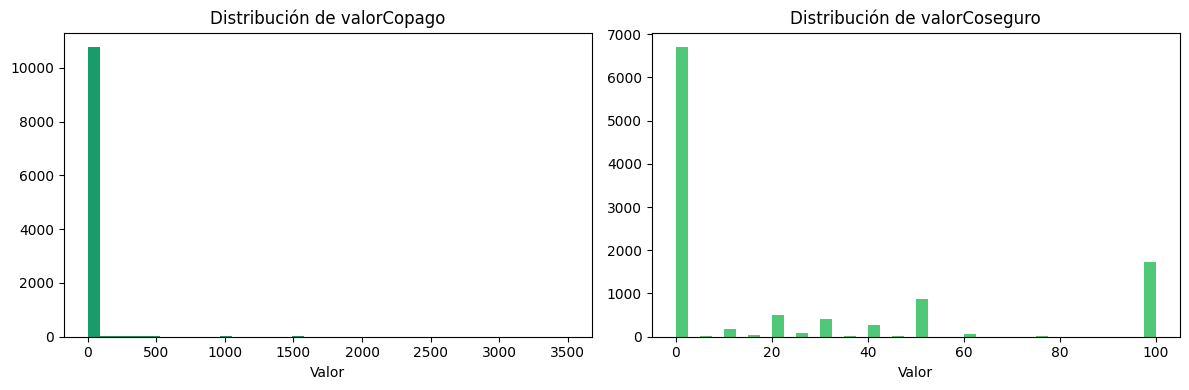

In [ ]:
import matplotlib.pyplot as plt

muestra = df_planes_beneficio.select("valorCopago", "valorCoseguro").sample(0.3, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(muestra["valorCopago"], bins=40, color="#189c6b")
axes[0].set_title("Distribución de valorCopago")
axes[0].set_xlabel("Valor")

axes[1].hist(muestra["valorCoseguro"], bins=40, color="#50C878")
axes[1].set_title("Distribución de valorCoseguro")
axes[1].set_xlabel("Valor")

plt.tight_layout()
plt.show()

*Nota: ambas distribuciones están fuertemente concentradas en valores bajos, con una
cola larga hacia la derecha — consistente con la alta desviación estándar observada
en `valorCopago` (100.41, más de 10 veces su media). Esta forma es esperable para
variables de costo de servicios de salud, donde la mayoría de los beneficios tienen
copagos o coseguros bajos, mientras que un subconjunto reducido de beneficios de alto
costo genera los valores extremos que sesgan el promedio.*

In [76]:
# Hay filas completas duplicadas en PlanesBeneficio?
duplicados_planes = df_planes_beneficio.groupBy(df_planes_beneficio.columns) \
    .count().filter(F.col("count") > 1)

total_duplicados = duplicados_planes.count()
print(f"Combinaciones de fila completa con más de 1 registro: {total_duplicados}")

if total_duplicados > 0:
    duplicados_planes.orderBy(F.desc("count")).show(5)

Combinaciones de fila completa con más de 1 registro: 8342


+-----------------+------------------+-------------------------+---------------------------+-----------------+-----------------+----------+-------------+-----------+-------------+--------------+-----+
|IdTipoBeneficio_T|IdAreaDeServicio_T|IdCondicionDePagoCopago_T|IdCondicionDePagoCoseguro_T|IdNivelServicio_T|         IdPlan_T|     Fecha|IdProveedor_T|valorCopago|valorCoseguro|cantidadLimite|count|
+-----------------+------------------+-------------------------+---------------------------+-----------------+-----------------+----------+-------------+-----------+-------------+--------------+-----+
|             NULL|          50152017|                      238|                         45|                2|38345WI0080018-03|2017-12-31|        38345|          0|            0|          NULL|   12|
|             NULL|          82642017|                      238|                         45|                2|67243LA0100009-01|2017-12-31|        67243|          0|            0|          NULL|  

In [77]:
# Cuánto del problema de duplicados de fila completa está concentrado en filas con IdTipoBeneficio_T nulo?
duplicados_con_id_nulo = duplicados_planes.filter(F.col("IdTipoBeneficio_T").isNull()).count()
duplicados_con_id_valido = duplicados_planes.filter(F.col("IdTipoBeneficio_T").isNotNull()).count()

print(f"Combinaciones duplicadas con IdTipoBeneficio_T nulo: {duplicados_con_id_nulo}")
print(f"Combinaciones duplicadas con IdTipoBeneficio_T válido: {duplicados_con_id_valido}")

# Cuántas filas en total representan estos 8,342 grupos (no solo el conteo de grupos, sino filas reales)
total_filas_en_duplicados = duplicados_planes.agg(F.sum("count")).collect()[0][0]
print(f"Filas totales involucradas en duplicados: {total_filas_en_duplicados} ({round(total_filas_en_duplicados/36036*100,2)}%)")

Combinaciones duplicadas con IdTipoBeneficio_T nulo: 527
Combinaciones duplicadas con IdTipoBeneficio_T válido: 7815


Filas totales involucradas en duplicados: 16835 (46.72%)


### 4.4 Análisis de calidad de datos

**Completitud:** dos llaves foráneas presentan valores nulos:

| Columna | Nulos | % |
|---|---|---|
| `IdTipoBeneficio_T` | 2,086 | 5.79% |
| `IdAreaDeServicio_T` | 2,041 | 5.67% |

Estas filas no pueden integrarse con las dimensiones `TiposBeneficio` ni
`AreasDeServicio` respectivamente, afectando directamente los análisis que requieren
esa integración (Análisis 2 y 4 de la matriz de temas analíticos).

La columna `cantidadLimite` presenta 30,571 nulos (84.85%); sin embargo, este valor es
consistente con la regla de negocio informada por RaSA ("los tipos de beneficio con
límite cuantitativo deben tener una cantidad límite diferente de cero") — dado que en
`TiposBeneficio`, el 64% de los tipos tiene `TieneLimiteCuantitativo = No`, es esperable
que la mayoría de los registros de `PlanesBeneficio` no tengan cantidad límite aplicable.

**Unicidad:** se identificaron 8,342 combinaciones de fila completa (todas las
columnas) con más de un registro idéntico, involucrando **16,835 filas (46.72% del
total de la fuente)**. Este es el hallazgo de mayor magnitud relativa de todo el
entendimiento de datos, superando incluso el nivel de duplicación observado en
`AreasDeServicio` (23.08%).

Se investigó si este patrón estaba concentrado en las filas con `IdTipoBeneficio_T`
nulo (ver hallazgo de Completitud anterior), pero se descartó esa hipótesis: solo el
6.3% de los grupos duplicados (527 de 8,342) tienen esta FK nula; el 93.7% restante
involucra registros con llaves completamente válidas. Esto indica que la duplicación
es un problema generalizado de la fuente, no un síntoma derivado de los registros
incompletos ya identificados.

Este hallazgo condiciona directamente la viabilidad de los cuatro análisis de la
matriz de temas analíticos (ver sección 7.1): cualquier tablero de control construido
sobre `PlanesBeneficio` sin una deduplicación previa sobrestimará sistemáticamente
los indicadores que dependan de conteos o sumas sobre esta fuente.

**Consistencia (integridad referencial):** se identificaron valores en las llaves
foráneas que no existen en sus respectivas tablas de dimensión:

| Llave foránea | Valores huérfanos | % sobre valores distintos |
|---|---|---|
| `IdTipoBeneficio_T` | 108 | 37.76% (108 de 286) |
| `IdAreaDeServicio_T` | 1,098 | 16.90% (1,098 de 6,497) |

Este hallazgo es crítico para la viabilidad de integración de fuentes: cualquier
análisis que requiera unir `PlanesBeneficio` con sus dimensiones perderá información
en ambos sentidos si no se trata este problema previamente (ver sección 7.3).

**Consistencia (formato de fecha):** la columna `Fecha` presenta el mismo año
representado en dos formatos distintos de texto:

| Formato | 2017 | 2018 |
|---|---|---|
| `YYYY-MM-DD` | 16,134 | 15,794 |
| `"Mon DD,YYYY"` | 1,029 | 1,027 |

Esta inconsistencia de formato no implica pérdida de información, pero requiere
normalización previa antes de cualquier análisis por fecha o año.

**Validez:** se identificaron 2,052 filas (5.7%) con `Fecha = 1920-12-31`, un año no
plausible para el contexto del negocio. Se validó que estas filas no coinciden con los
registros que presentan `IdTipoBeneficio_T` o `IdAreaDeServicio_T` nulos, por lo que se
trata de un hallazgo independiente. Adicionalmente, se confirmó que los 212 planes
(`IdPlan_T`) asociados a estas filas también existen bajo un año válido (2017 o 2018),
lo cual descarta que se trate de planes ficticios: el patrón es consistente con un
problema de duplicación de registros con corrupción del campo fecha durante el proceso
de carga, más que con datos inventados.

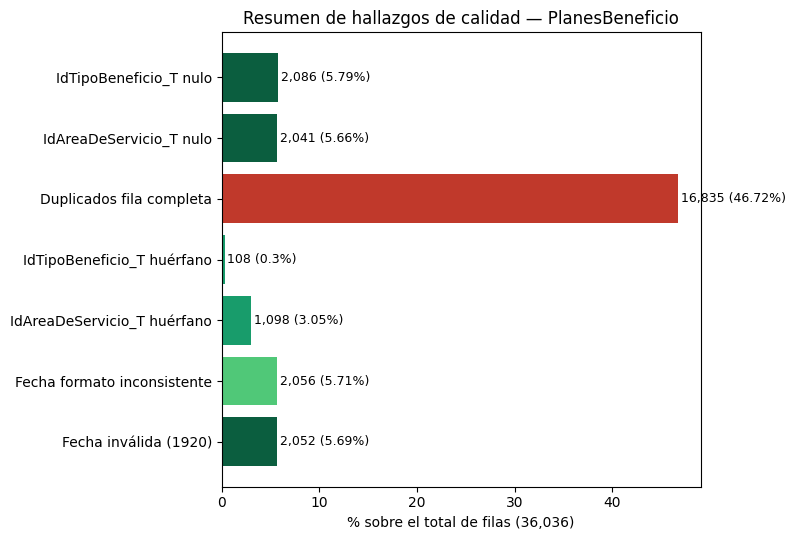

In [78]:
import matplotlib.pyplot as plt

hallazgos_planes = [
    "IdTipoBeneficio_T nulo",
    "IdAreaDeServicio_T nulo",
    "Duplicados fila completa",
    "IdTipoBeneficio_T huérfano",
    "IdAreaDeServicio_T huérfano",
    "Fecha formato inconsistente",
    "Fecha inválida (1920)"
]

total_filas = 36036
magnitudes = [2086, 2041, 16835, 108, 1098, 2056, 2052]
porcentajes = [round(m / total_filas * 100, 2) for m in magnitudes]

colores = ["#0b5e3f", "#0b5e3f", "#c0392b", "#189c6b", "#189c6b", "#50C878", "#0b5e3f"]

fig, ax = plt.subplots(figsize=(8, 5.5))
barras = ax.barh(hallazgos_planes, porcentajes, color=colores)

ax.set_xlabel("% sobre el total de filas (36,036)")
ax.set_title("Resumen de hallazgos de calidad — PlanesBeneficio")
ax.invert_yaxis()

for barra, magnitud, pct in zip(barras, magnitudes, porcentajes):
    ax.text(barra.get_width() + 0.3, barra.get_y() + barra.get_height()/2,
             f"{magnitud:,} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

*Nota: los porcentajes de la gráfica están calculados sobre el total de filas de la
fuente (36,036), para mantener comparabilidad entre hallazgos. Los hallazgos de
integridad referencial (`IdTipoBeneficio_T` e `IdAreaDeServicio_T` huérfanos) se
reportan en la tabla de la sección 4.4 sobre el total de valores distintos de cada
columna, por lo que sus porcentajes difieren de los mostrados aquí (37.76% y 16.90%
respectivamente, en lugar de 0.3% y 3.05%). El hallazgo de duplicados de fila completa
(46.72%) es, por un margen amplio, el de mayor magnitud de esta fuente y del
entendimiento de datos en general — se destaca en rojo por su impacto directo sobre la
viabilidad de los cuatro análisis de la matriz de temas analíticos (ver sección 7.1).*

## 5. Fuente 4: CondicionesDePago

### 5.1 Perfilamiento de datos

La tabla `FuenteCondicionesDePago_Copia_E` contiene **31 filas** y **3 columnas**:

| Columna | Tipo de dato |
|---|---|
| IdCondicionesDePago_T | integer |
| Descripcion | string |
| Tipo | string |

El negocio reportó 15 condiciones de copago y 5 de coseguro (20 en total). La fuente
contiene 31 filas — 11 registros adicionales a lo esperado, a investigar en esta
sección.

In [ ]:
# Nulos por columna
df_condiciones_pago.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c + "_nulos") for c in df_condiciones_pago.columns
]).show()

# Valores distintos por columna
for c in df_condiciones_pago.columns:
    print(c, "->", df_condiciones_pago.select(c).distinct().count(), "valores distintos")

# Detalle de la columna Tipo
df_condiciones_pago.groupBy("Tipo").count().orderBy(F.desc("count")).show()

# ¿Descripcion es única, o hay duplicados de texto bajo distinto ID?
dup_descripcion = df_condiciones_pago.groupBy("Descripcion") \
    .agg(F.countDistinct("IdCondicionesDePago_T").alias("ids_distintos")) \
    .filter(F.col("ids_distintos") > 1).count()
print(f"Descripciones con más de un ID asociado: {dup_descripcion}")

+---------------------------+-----------------+----------+
|IdCondicionesDePago_T_nulos|Descripcion_nulos|Tipo_nulos|
+---------------------------+-----------------+----------+
|                          0|                0|         0|
+---------------------------+-----------------+----------+



IdCondicionesDePago_T -> 23 valores distintos
Descripcion -> 17 valores distintos
Tipo -> 6 valores distintos
+-------------+-----+
|         Tipo|count|
+-------------+-----+
|       Copago|   19|
|     Coseguro|    7|
|          NaN|    2|
|     Copagado|    1|
|  Coseguridad|    1|
|SinTipoCopago|    1|
+-------------+-----+

Descripciones con más de un ID asociado: 7


In [ ]:
# Los IDs repetidos tienen la MISMA descripción/tipo, o varían?
ids_repetidos = df_condiciones_pago.groupBy("IdCondicionesDePago_T").count().filter(F.col("count") > 1)

df_condiciones_pago.join(ids_repetidos, "IdCondicionesDePago_T") \
    .orderBy("IdCondicionesDePago_T") \
    .show(20, truncate=False)

+---------------------+-------------------------------+--------+-----+
|IdCondicionesDePago_T|Descripcion                    |Tipo    |count|
+---------------------+-------------------------------+--------+-----+
|27                   |Coinsurance after deductible   |Coseguro|2    |
|27                   |Coinsurance after deductible   |Coseguro|2    |
|45                   |Coinsurance                    |Coseguro|2    |
|45                   |Coinsurance                    |Coseguro|2    |
|51                   |No Charge                      |Copago  |2    |
|51                   |No Charge                      |Copago  |2    |
|119                  |Copay per Day with deductible  |Copago  |2    |
|119                  |Copay per Day with deductible  |Copago  |2    |
|204                  |Copay per Day                  |Copago  |3    |
|204                  |Copay per Stay after deductible|Copago  |3    |
|204                  |Copay per Stay after deductible|Copago  |3    |
|207  

In [ ]:
# Cuántas filas de PlanesBeneficio usan el ID 204 como condición de copago o coseguro?
afectadas_204 = df_planes_beneficio.filter(
    (F.col("IdCondicionDePagoCopago_T") == 204) | (F.col("IdCondicionDePagoCoseguro_T") == 204)
).count()
print(f"Filas de PlanesBeneficio que referencian el ID 204 (ambiguo): {afectadas_204}")

# Resumen final: cuántos IDs de CondicionesDePago están duplicados en total (exactos + ambiguos)
df_condiciones_pago.groupBy("IdCondicionesDePago_T").count().filter(F.col("count") > 1).count()

Filas de PlanesBeneficio que referencian el ID 204 (ambiguo): 15


7

### 5.2 Significado de una fila

Cada fila representa una condición de pago (copago o coseguro) que puede aplicarse a
un beneficio dentro de un plan, identificada por `IdCondicionesDePago_T` y descrita en
`Descripcion`, clasificada por `Tipo` (Copago o Coseguro). Esta tabla funciona como
catálogo de referencia, utilizado por `PlanesBeneficio` a través de dos llaves
foráneas con roles distintos (`IdCondicionDePagoCopago_T` e
`IdCondicionDePagoCoseguro_T`).

El negocio reportó 15 condiciones de copago y 5 de coseguro (20 en total); la fuente
contiene 31 filas y 23 valores distintos de `IdCondicionesDePago_T` — discrepancias
que se explican en el análisis de calidad de datos a continuación.

In [ ]:
from pyspark.sql import functions as F

total = df_condiciones_pago.count()

# Moda de Tipo
moda_tipo = df_condiciones_pago.groupBy("Tipo").count().orderBy(F.desc("count")).first()
print(f"Tipo más frecuente: '{moda_tipo['Tipo']}' ({moda_tipo['count']} filas, {round(moda_tipo['count']/total*100,2)}%)")

# Longitud promedio de Descripcion (para detectar si hay descripciones anómalamente cortas/largas)
df_condiciones_pago.select(
    F.avg(F.length("Descripcion")).alias("longitud_promedio"),
    F.min(F.length("Descripcion")).alias("longitud_min"),
    F.max(F.length("Descripcion")).alias("longitud_max")
).show()

# Distribución de filas por Tipo agrupando las variantes (Copago/Copagado juntas, Coseguro/Coseguridad juntas)
df_condiciones_pago.withColumn(
    "Tipo_normalizado",
    F.when(F.col("Tipo").isin("Copago", "Copagado", "SinTipoCopago"), "Copago")
     .when(F.col("Tipo").isin("Coseguro", "Coseguridad"), "Coseguro")
     .otherwise("Sin clasificar")
).groupBy("Tipo_normalizado").count().orderBy(F.desc("count")).show()

Tipo más frecuente: 'Copago' (19 filas, 61.29%)
+------------------+------------+------------+
| longitud_promedio|longitud_min|longitud_max|
+------------------+------------+------------+
|20.225806451612904|           5|          32|
+------------------+------------+------------+

+----------------+-----+
|Tipo_normalizado|count|
+----------------+-----+
|          Copago|   21|
|        Coseguro|    8|
|  Sin clasificar|    2|
+----------------+-----+



### 5.3 Estadísticas descriptivas

La columna `Tipo` está dominada por la categoría "Copago" en su forma original (19
filas, 61.29%). Al normalizar las variantes textuales ya identificadas como
equivalentes (`Copagado` y `SinTipoCopago` bajo "Copago"; `Coseguridad` bajo
"Coseguro"), la distribución queda en **21 filas de Copago y 8 de Coseguro** (29 de 31
filas clasificadas), acercándose más a la proporción reportada por el negocio (15
condiciones de copago y 5 de coseguro). Las 2 filas restantes corresponden a valores
`NaN` en `Tipo`, que permanecen sin clasificar.

La columna `Descripcion` tiene una longitud promedio de 20.2 caracteres, con un rango
de 5 a 32 caracteres — sin valores atípicamente cortos o largos que sugieran texto
truncado o corrupto.

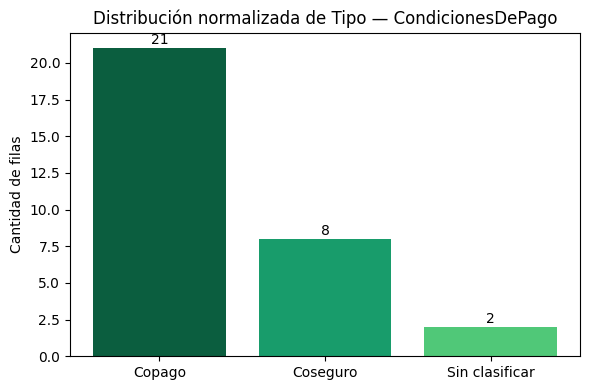

In [ ]:
import matplotlib.pyplot as plt

tipo_normalizado = df_condiciones_pago.withColumn(
    "Tipo_normalizado",
    F.when(F.col("Tipo").isin("Copago", "Copagado", "SinTipoCopago"), "Copago")
     .when(F.col("Tipo").isin("Coseguro", "Coseguridad"), "Coseguro")
     .otherwise("Sin clasificar")
).groupBy("Tipo_normalizado").count().orderBy(F.desc("count")).toPandas()

colores = {"Copago": "#0b5e3f", "Coseguro": "#189c6b", "Sin clasificar": "#50C878"}
colores_barras = [colores[t] for t in tipo_normalizado["Tipo_normalizado"]]

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(tipo_normalizado["Tipo_normalizado"], tipo_normalizado["count"], color=colores_barras)

ax.set_ylabel("Cantidad de filas")
ax.set_title("Distribución normalizada de Tipo — CondicionesDePago")

for barra, valor in zip(barras, tipo_normalizado["count"]):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
             str(valor), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

*Nota: la gráfica muestra la distribución de `Tipo` tras normalizar las variantes
textuales identificadas como equivalentes (`Copagado`→Copago, `SinTipoCopago`→Copago,
`Coseguridad`→Coseguro). El resultado (21 Copago, 8 Coseguro, 2 sin clasificar) se
acerca más a la proporción reportada por el negocio (15 y 5 respectivamente) que la
distribución cruda de 6 categorías observada originalmente, respaldando la hipótesis
de que se trata de variantes de un mismo catálogo de 2 valores, capturadas de forma
inconsistente.*

In [79]:
# Validez: ¿IdCondicionesDePago_T tiene valores fuera de rango razonable (negativos, cero)?
df_condiciones_pago.select(
    F.min("IdCondicionesDePago_T").alias("id_min"),
    F.max("IdCondicionesDePago_T").alias("id_max")
).show()

# Validez: ¿alguna Descripcion vacía o solo espacios en blanco?
vacias = df_condiciones_pago.filter(F.trim(F.col("Descripcion")) == "").count()
print(f"Descripciones vacías o solo espacios: {vacias}")

# Validez: ¿algún Tipo vacío o solo espacios (más allá de los ya vistos como NaN)?
tipo_vacio = df_condiciones_pago.filter(F.trim(F.col("Tipo")) == "").count()
print(f"Valores de Tipo vacíos o solo espacios: {tipo_vacio}")

+------+------+
|id_min|id_max|
+------+------+
|     9|   714|
+------+------+

Descripciones vacías o solo espacios: 0
Valores de Tipo vacíos o solo espacios: 0


### 5.4 Análisis de calidad de datos

**Completitud:** la fuente no presenta valores nulos en ninguna de sus 3 columnas.

**Unicidad (llave primaria):** `IdCondicionesDePago_T`, que debería funcionar como
llave primaria del catálogo, no es único: de 31 filas, solo existen 23 valores
distintos. Se identificaron 7 IDs con más de un registro asociado:

| Tipo de duplicado | IDs afectados | Descripción |
|---|---|---|
| Duplicado exacto | 27, 45, 51, 119, 207, 221 | Mismo ID, misma `Descripcion` y `Tipo` en ambas ocurrencias — inofensivo, resoluble con deduplicación simple |
| Duplicado con datos distintos | 204 | Mismo ID asociado a dos condiciones conceptualmente distintas: "Copay per Day" y "Copay per Stay after deductible" (ambas Copago) |

El caso del ID `204` es el hallazgo más grave de esta fuente: al no ser posible
determinar cuál de las dos descripciones corresponde a cada referencia, cualquier
plan que use este ID queda con ambigüedad irresoluble en su condición de pago. Se
cuantificó el impacto directo sobre la tabla de hechos: **15 filas de
`PlanesBeneficio`** referencian el ID `204` (como condición de copago o coseguro),
quedando afectadas por esta ambigüedad.

**Consistencia (catálogo de `Tipo`):** la columna `Tipo`, que conceptualmente debería
tomar solo dos valores (Copago, Coseguro), presenta 6 valores distintos:

| Valor | Conteo |
|---|---|
| Copago | 19 |
| Coseguro | 7 |
| NaN | 2 |
| Copagado | 1 |
| Coseguridad | 1 |
| SinTipoCopago | 1 |

Los valores `Copagado` y `Coseguridad` son variantes textuales de `Copago` y
`Coseguro` respectivamente; `SinTipoCopago` sugiere una condición sin tipo asignado
que debería tratarse como nulo o categoría aparte; y `NaN` (2 filas) representa
valores explícitamente faltantes. Este patrón es consistente con el mismo problema
de falta de estandarización de catálogo observado en `TiposBeneficio`.

**Consistencia (catálogo redundante):** 7 de las 17 descripciones distintas están
asociadas a más de un `IdCondicionesDePago_T`, incluyendo casos donde la misma
condición conceptual (por ejemplo, "No Charge after deductible") aparece registrada
bajo distintos IDs. Esto indica que, además de los IDs duplicados, el catálogo mismo
tiene entradas redundantes que deberían consolidarse.

**Validez:** se verificó que `IdCondicionesDePago_T` no presenta valores negativos,
cero, o fuera de un rango razonable (rango observado: 9 a 714); y que ni
`Descripcion` ni `Tipo` contienen valores vacíos o compuestos solo por espacios en
blanco que pudieran representar datos "presentes" sin contenido real. No se
identificaron hallazgos de Validez en esta fuente.

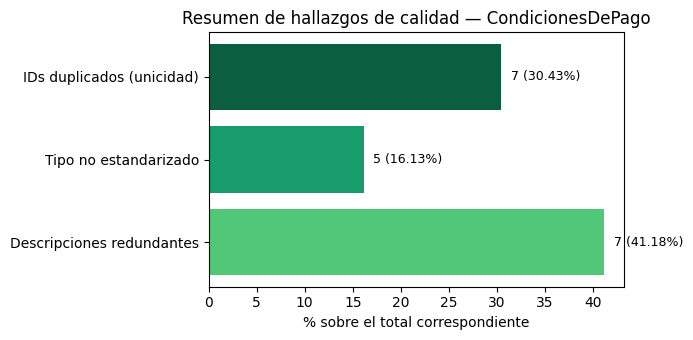

In [ ]:
hallazgos_condiciones = [
    "IDs duplicados (unicidad)",
    "Tipo no estandarizado",
    "Descripciones redundantes"
]

# Cada hallazgo usa su propio denominador conceptual (aclarado en la nota)
magnitudes = [7, 5, 7]
totales =    [23, 31, 17]  # IDs distintos, filas totales, descripciones distintas
porcentajes = [round(m / t * 100, 2) for m, t in zip(magnitudes, totales)]

colores = ["#0b5e3f", "#189c6b", "#50C878"]

fig, ax = plt.subplots(figsize=(7, 3.5))
barras = ax.barh(hallazgos_condiciones, porcentajes, color=colores)

ax.set_xlabel("% sobre el total correspondiente")
ax.set_title("Resumen de hallazgos de calidad — CondicionesDePago")
ax.invert_yaxis()

for barra, magnitud, pct in zip(barras, magnitudes, porcentajes):
    ax.text(barra.get_width() + 1, barra.get_y() + barra.get_height()/2,
             f"{magnitud} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

*Nota: dado el tamaño reducido de esta fuente (31 filas), cada hallazgo se calcula
sobre su propio denominador conceptual para reflejar mejor su magnitud relativa: IDs
duplicados sobre el total de valores distintos de `IdCondicionesDePago_T` (23), Tipo
no estandarizado sobre el total de filas (31), y descripciones redundantes sobre el
total de descripciones distintas (17). La dimensión de Validez también fue evaluada
(rango de ID, campos vacíos) y no arrojó hallazgos, por lo que no se incluye una
barra adicional. Adicionalmente, se cuantificó el impacto del caso más grave (ID
`204`, con datos ambiguos) sobre la tabla de hechos: 15 filas de `PlanesBeneficio`
referencian este ID y quedan afectadas por la ambigüedad.*

## 6. Validación contra los datos de negocio informados por RaSA

RaSA compartió, en el enunciado del proyecto, una serie de cifras y reglas de negocio
como referencia. Esta sección consolida el contraste entre lo declarado por el
negocio y lo observado en las fuentes, con base en la evidencia generada en las
secciones 2 a 5.

| # | Dato del enunciado | Dato observado en la fuente | Estado | Evidencia |
|---|---|---|---|---|
| 1 | 5,409 áreas de servicio | 5,410 valores distintos de `IdAreaDeServicio_T` | Consistente | Sección 2.1 |
| 2 | 170 tipos de beneficio | 178 valores distintos de `IdTipoBeneficio_T` | Diferencia de 8 | Sección 3.2 |
| 3 | Cobertura de años 2017-2019 en AreasDeServicio y TiposBeneficio | Ambas fuentes solo contienen 2017-2018; 2019 ausente | No se cumple | Secciones 2.4, 3.4 |
| 4 | 301 planes en 2017, 422 en 2018 (723 total) | 393 valores distintos de `IdPlan_T` en toda la fuente | Faltan 330 planes | Sección 4.2 |
| 5 | Máximo Copago 2018 = 3,300 | 8 filas de 2018 superan este máximo (máx. real: 3,500) | No se cumple | Sección 4.3 |
| 6 | Máximo Coseguro 2018 = 100 | Ninguna fila de 2018 supera este máximo | Consistente | Sección 4.3 |
| 7 | 15 condiciones de copago, 5 de coseguro (20 total) | 31 filas; 21 Copago y 8 Coseguro tras normalizar variantes textuales | 9 registros de más | Sección 5.3 |
| 8 | Regla: tipos con límite cuantitativo deben tener cantidad límite ≠ 0 | No se pudo validar de forma confiable (ver 6.1) | No verificable | Sección 6.1 |

De las 8 validaciones, 2 son totalmente consistentes con el negocio, 3 muestran
diferencias menores que ameritan aclaración, y 3 revelan discrepancias significativas
que condicionan la viabilidad de los análisis solicitados (ver Entregable 3,
conclusiones).

**Nota adicional — hallazgo de Unicidad en PlanesBeneficio:** más allá de las
validaciones contra cifras específicas del enunciado, el proceso de entendimiento de
datos reveló un hallazgo que no proviene de un dato de negocio declarado, pero que es
central para la confiabilidad de cualquier análisis: el 46.72% de las filas de
`PlanesBeneficio` (16,835 de 36,036) están involucradas en duplicados de fila
completa (ver sección 4.4). Este hallazgo se suma a las limitaciones de integración
ya documentadas —integridad referencial rota hacia `TiposBeneficio` y
`AreasDeServicio`, y la ambigüedad estructural de `TiposBeneficio`— y refuerza la
conclusión general de esta sección: **`PlanesBeneficio` requiere un proceso de
limpieza y deduplicación previo a cualquier uso analítico**, independientemente de
si se están validando cifras específicas del negocio o construyendo los tableros de
control solicitados.

In [71]:
# Demostración del efecto de fan-out al cruzar PlanesBeneficio con TiposBeneficio
# (el hallazgo de que IdTipoBeneficio_T+Fecha no es único en TiposBeneficio
# ya fue confirmado y cuantificado en las secciones 3.2 y 3.4)

planes_alias = df_planes_beneficio.withColumn(
    "Anio", F.substring(F.col("Fecha"), 1, 4).cast("int")
).filter(F.col("Fecha").isin("2017-12-31", "2018-12-31")).alias("planes")

tipos_alias = df_tipos_beneficio.select(
    "IdTipoBeneficio_T", "TieneLimiteCuantitativo", "Fecha"
).withColumnRenamed("Fecha", "Anio_tipo").alias("tipos")

cruce_inflado = planes_alias.join(
    tipos_alias,
    (F.col("planes.IdTipoBeneficio_T") == F.col("tipos.IdTipoBeneficio_T")) &
    (F.col("planes.Anio") == F.col("tipos.Anio_tipo")),
    "inner"
)

filas_originales = planes_alias.count()
filas_cruce = cruce_inflado.count()

print(f"Filas de PlanesBeneficio con año válido (2017/2018): {filas_originales}")
print(f"Filas resultantes al cruzar con TiposBeneficio: {filas_cruce}")
print(f"Factor de inflación: {round(filas_cruce/filas_originales, 2)}x")

Filas de PlanesBeneficio con año válido (2017/2018): 31928
Filas resultantes al cruzar con TiposBeneficio: 130059
Factor de inflación: 4.07x


### 6.1 Nota sobre la validación de la regla "TieneLimiteCuantitativo → cantidadLimite"

Se intentó validar esta regla de negocio cruzando `PlanesBeneficio` con
`TiposBeneficio` por `IdTipoBeneficio_T` + año. Sin embargo, dado que esta
combinación no es única en `TiposBeneficio` —161 combinaciones ID+año presentan
entre 2 y 25 configuraciones distintas cada una, con valores genuinamente diferentes
en columnas como `EsEHB` y `TieneLimiteCuantitativo` (ver hallazgo de Unicidad en la
sección 3.4)—, el cruce genera un efecto de multiplicación de filas (*fan-out*): cada
fila de `PlanesBeneficio` se combina con todas las configuraciones de `TiposBeneficio`
que comparten ID y año.

Se cuantificó este efecto sobre las 31,928 filas de `PlanesBeneficio` con año válido
(2017 o 2018): el cruce con `TiposBeneficio` produce **130,059 filas**, un factor de
inflación de **4.07 veces** el total original.

**Esta regla de negocio no puede validarse de forma confiable con las fuentes
actuales**, ya que no existe una llave común entre ambas tablas que garantice una
correspondencia 1 a 1. Cualquier cifra de "incumplimientos" calculada sobre este cruce
inflado sería artificialmente alta y no representativa. Se reporta como limitación en
la sección de conclusiones (Entregable 3), junto con la recomendación de solicitar a
RaSA una columna adicional en `TiposBeneficio` (posiblemente `IdPlan_T` o
`IdProveedor_T`) que permita esta integración sin ambigüedad.

## 7. Conclusión del entendimiento de datos

Esta sección consolida las conclusiones del proceso de entendimiento de datos,
evaluando la viabilidad de los análisis solicitados por RaSA, sintetizando el
significado de los datos analizados, concluyendo sobre la posibilidad de integrar las
fuentes, y documentando las dudas y supuestos identificados a lo largo del proceso.

### 7.1 Viabilidad de los análisis propuestos

| Análisis | Viabilidad | Justificación |
|---|---|---|
| **1. Comportamiento desleal de proveedores** (1.a, 1.b) | Viable con ajustes | Requiere `TiposBeneficio` + `BeneficiosPlanes`. La integración entre ambas está comprometida: `TiposBeneficio` no tiene una llave única por tipo+año (sección 3.2/3.4), y 108 valores de `IdTipoBeneficio_T` en `PlanesBeneficio` no existen en la dimensión (sección 4.4). Adicionalmente, el 46.72% de las filas de `PlanesBeneficio` están involucradas en duplicados de fila completa (sección 4.4) — sin deduplicar, la comparación de copago/coseguro entre proveedores estaría distorsionada por registros repetidos. El análisis es viable únicamente si se excluyen los registros huérfanos, se deduplica la tabla de hechos, y se acepta como limitación la ambigüedad de `TiposBeneficio`. |
| **2. Cobertura de planes** (2.a, 2.b, 2.c) | Viable con ajustes | Requiere `AreasDeServicio` + `BeneficiosPlanes`. El 23.08% de las combinaciones área+condado+estado están duplicadas (sección 2.4), 1,098 valores de `IdAreaDeServicio_T` en `PlanesBeneficio` no existen en la dimensión, y el 46.72% de `PlanesBeneficio` tiene filas completas duplicadas (sección 4.4). Cualquier conteo de cobertura debe aplicar deduplicación en ambas fuentes antes de calcularse, o los resultados sobreestimarán la cobertura real de forma significativa. |
| **3. Concentraciones de planes** (3.a, 3.b) | Viable con ajustes | Misma dependencia y limitaciones que el Análisis 2 (duplicados en `AreasDeServicio`, huérfanos y duplicados de fila completa en `PlanesBeneficio`). Adicionalmente, el análisis 3.b requiere `PoblacionAct`, que presenta errores de escala en 1.55% de los registros (sección 2.4). Sin deduplicar `PlanesBeneficio`, cualquier conteo de "cuántos planes hay por área" estaría inflado hasta en un 46.72%. |
| **4. Evolución de planes** (4.a, 4.b) | Viable con ajustes | Requiere `TiposBeneficio` + `BeneficiosPlanes` a través del tiempo. Se ve afectado por la ausencia del año 2019 en `TiposBeneficio`, y hereda tanto la limitación de integración de tipo de beneficio (Análisis 1) como el hallazgo de duplicados de fila completa en `PlanesBeneficio` — una evolución de costos calculada sobre datos duplicados podría mostrar tendencias artificiales si la duplicación no es uniforme entre años. |

**Ningún análisis de la matriz es inviable de forma absoluta**, pero los cuatro
dependen de tratamientos previos de calidad — deduplicación, exclusión de huérfanos,
y corrección o exclusión de outliers — antes de poder construirse como tableros de
control confiables. El hallazgo más transversal es la duplicación de fila completa en
`PlanesBeneficio` (46.72% de sus filas, sección 4.4): al ser la tabla de hechos que
alimenta los cuatro análisis, este único problema condiciona la confiabilidad de todo
el modelo si no se resuelve antes de construir los tableros. El Análisis 1 y 4 son
adicionalmente los más comprometidos por depender de una integración limpia con
`TiposBeneficio`, cuya llave natural no pudo determinarse con las columnas
disponibles (sección 3.2).

### 7.2 Síntesis de lo que representa la fila promedio

| Fuente | Significado de una fila | Particularidad relevante |
|---|---|---|
| `AreasDeServicio` | La combinación entre un área de servicio (asociada a un plan o proveedor específico) y un condado geográfico cubierto por dicha área. | No existe una fila por área; existe una fila por cada condado que un área cubre — de ahí que 5,410 áreas generen 188,815 filas. |
| `TiposBeneficio` | Se esperaba que fuera "un tipo de beneficio, reportado para un año dado", pero esta hipótesis no pudo confirmarse: 161 combinaciones de tipo+año presentan múltiples configuraciones distintas, sin que ninguna columna disponible permita diferenciarlas de forma única. | Es la única de las cuatro fuentes donde no fue posible determinar una llave natural completa con las columnas provistas. |
| `BeneficiosPlanes` | La asignación de un tipo de beneficio específico a un plan de salud, en un área de servicio determinada, con sus condiciones de pago y su valor asociado. Es la tabla de hechos central del modelo. | Conecta las tres dimensiones del proyecto, pero hereda la ambigüedad de `TiposBeneficio` y presenta huérfanos hacia ambas dimensiones (`IdTipoBeneficio_T` e `IdAreaDeServicio_T`). |
| `CondicionesDePago` | Una condición de pago (copago o coseguro) aplicable a un beneficio dentro de un plan. Funciona como catálogo de referencia. | Su llave primaria (`IdCondicionesDePago_T`) no es única: 7 IDs tienen más de un registro, incluyendo un caso (`204`) con datos conceptualmente distintos bajo el mismo identificador. |

En conjunto, las cuatro fuentes describen el ciclo de oferta de planes de salud: qué
beneficios existen (`TiposBeneficio`), en qué zonas se ofrecen (`AreasDeServicio`),
bajo qué condiciones de pago (`CondicionesDePago`), y cómo se combinan en cada plan
concreto (`BeneficiosPlanes`, la tabla de hechos). Sin embargo, tres de las cuatro
fuentes presentan algún grado de ambigüedad en su llave natural — la fuente más
crítica en este sentido es `TiposBeneficio`, cuya llave incompleta condiciona
directamente la confiabilidad de cualquier análisis que dependa de tipos de
beneficio (Análisis 1 y 4 de la matriz).

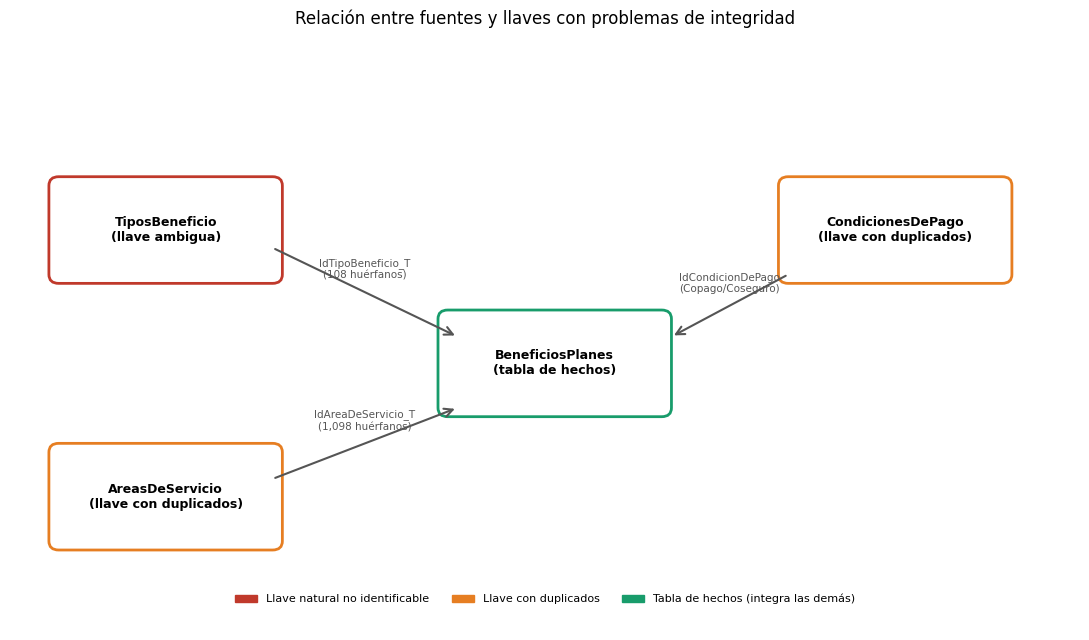

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6.5)
ax.axis("off")

# Definición de cajas: (x, y, texto, color de borde)
cajas = {
    "TiposBeneficio": (0.5, 4, "TiposBeneficio\n(llave ambigua)", "#c0392b"),
    "AreasDeServicio": (0.5, 1, "AreasDeServicio\n(llave con duplicados)", "#e67e22"),
    "BeneficiosPlanes": (4.5, 2.5, "BeneficiosPlanes\n(tabla de hechos)", "#189c6b"),
    "CondicionesDePago": (8, 4, "CondicionesDePago\n(llave con duplicados)", "#e67e22"),
}

for nombre, (x, y, texto, color) in cajas.items():
    box = FancyBboxPatch((x, y), 2.2, 1, boxstyle="round,pad=0.1",
                          linewidth=2, edgecolor=color, facecolor="white")
    ax.add_patch(box)
    ax.text(x + 1.1, y + 0.5, texto, ha="center", va="center", fontsize=9, weight="bold")

# Flechas hacia BeneficiosPlanes (tabla de hechos central)
flechas = [
    ((2.7, 4.3), (4.6, 3.3), "IdTipoBeneficio_T\n(108 huérfanos)"),
    ((2.7, 1.7), (4.6, 2.5), "IdAreaDeServicio_T\n(1,098 huérfanos)"),
    ((8.0, 4.0), (6.8, 3.3), "IdCondicionDePago\n(Copago/Coseguro)"),
]

for inicio, fin, etiqueta in flechas:
    arrow = FancyArrowPatch(inicio, fin, arrowstyle="->", mutation_scale=15,
                             color="#555555", linewidth=1.5)
    ax.add_patch(arrow)
    mx, my = (inicio[0]+fin[0])/2, (inicio[1]+fin[1])/2
    ax.text(mx, my + 0.15, etiqueta, ha="center", fontsize=7.5, color="#555555")

ax.set_title("Relación entre fuentes y llaves con problemas de integridad", fontsize=12, pad=20)

# Leyenda
rojo = mpatches.Patch(color="#c0392b", label="Llave natural no identificable")
naranja = mpatches.Patch(color="#e67e22", label="Llave con duplicados")
verde = mpatches.Patch(color="#189c6b", label="Tabla de hechos (integra las demás)")
ax.legend(handles=[rojo, naranja, verde], loc="upper center",
          bbox_to_anchor=(0.5, 0.08), ncol=3, fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

*Nota: el diagrama resume las relaciones entre las cuatro fuentes y su estado de
integridad. `BeneficiosPlanes` actúa como tabla de hechos, integrando las tres
dimensiones. `TiposBeneficio` es la fuente más crítica (llave natural no
identificable con las columnas disponibles), mientras que `AreasDeServicio` y
`CondicionesDePago` presentan duplicados en su llave que requieren tratamiento previo
antes de integrarse de forma confiable con la tabla de hechos.*

### 7.3 Conclusión sobre la integración de las fuentes

Las cuatro fuentes pueden integrarse a través de las siguientes columnas, aunque con
distintos niveles de confiabilidad:

| Relación | Columna de unión | Confiabilidad |
|---|---|---|
| `BeneficiosPlanes` ↔ `AreasDeServicio` | `IdAreaDeServicio_T` | Parcial — 1,098 valores huérfanos en `BeneficiosPlanes` (5.67% de las filas quedan sin dimensión); adicionalmente, `AreasDeServicio` tiene 23.08% de su llave natural duplicada, por lo que se recomienda deduplicar antes de unir. |
| `BeneficiosPlanes` ↔ `TiposBeneficio` | `IdTipoBeneficio_T` (+ año, idealmente) | No confiable — 108 valores huérfanos en `BeneficiosPlanes`, y `TiposBeneficio` no tiene una llave única por tipo+año (fan-out de 4.07x al intentar el cruce, ver sección 6.1). No se recomienda integrar estas fuentes sin antes resolver la ambigüedad de `TiposBeneficio` con RaSA. |
| `BeneficiosPlanes` ↔ `CondicionesDePago` | `IdCondicionDePagoCopago_T` / `IdCondicionDePagoCoseguro_T` | Parcial — la fuente tiene 0% de nulos en las llaves foráneas, pero `CondicionesDePago` tiene 7 IDs duplicados, incluyendo un caso (`204`) con datos ambiguos que afecta 15 filas de `BeneficiosPlanes`. |

**Conclusión general:** la integración completa del modelo (las 4 fuentes unidas) no
es posible de forma confiable con los datos actuales. La relación más crítica es
`BeneficiosPlanes` ↔ `TiposBeneficio`, ya que ninguna combinación de columnas
disponibles en `TiposBeneficio` garantiza unicidad — este es un problema estructural
de la fuente, no solo de calidad de datos, y requiere intervención de RaSA (ya sea
agregando una columna faltante o aclarando el diseño esperado de la tabla) antes de
poder construir los tableros de control de forma confiable para los Análisis 1 y 4 de
la matriz.

Las relaciones con `AreasDeServicio` y `CondicionesDePago` sí son viables, siempre que
se aplique deduplicación de la llave natural como paso previo de limpieza.

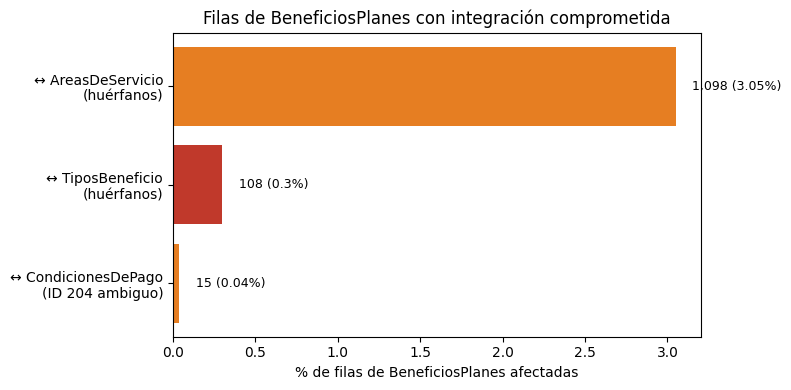

In [75]:
import matplotlib.pyplot as plt

relaciones = [
    "↔ AreasDeServicio\n(huérfanos)",
    "↔ TiposBeneficio\n(huérfanos)",
    "↔ CondicionesDePago\n(ID 204 ambiguo)"
]

total_filas = 36036
magnitudes = [1098, 108, 15]
porcentajes = [round(m / total_filas * 100, 2) for m in magnitudes]

# Colores según nivel de riesgo: TiposBeneficio es el más crítico aunque
# tenga menos filas huérfanas, porque además tiene el problema estructural de fan-out
colores = ["#e67e22", "#c0392b", "#e67e22"]

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(relaciones, porcentajes, color=colores)

ax.set_xlabel("% de filas de BeneficiosPlanes afectadas")
ax.set_title("Filas de BeneficiosPlanes con integración comprometida")
ax.invert_yaxis()

for barra, magnitud, pct in zip(barras, magnitudes, porcentajes):
    ax.text(barra.get_width() + 0.1, barra.get_y() + barra.get_height()/2,
             f"{magnitud:,} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

*Nota: aunque `TiposBeneficio` presenta menos filas huérfanas en términos absolutos
(108, 0.30%) que `AreasDeServicio` (1,098, 3.05%), se marca en rojo por tratarse de un
problema estructural —ausencia de llave única— y no solo de completitud: el intento
de integración con esta fuente genera un fan-out de 4.07x (sección 6.1), lo cual la
convierte en la relación más riesgosa de las tres, independientemente de su magnitud
en filas afectadas.*

### 7.4 Lista de dudas y supuestos

A lo largo del entendimiento de datos se identificaron las siguientes dudas, que se
proponen trasladar a RaSA para su aclaración antes de avanzar a las siguientes etapas
del proyecto:

**Dudas sobre cobertura y alcance de las fuentes**
1. `TiposBeneficio` no contiene registros del año 2019, aunque el enunciado indica
   cobertura 2017-2019 para esta fuente. ¿Falta cargar ese año, o cambió el alcance
   temporal del proyecto?
2. La fuente `BeneficiosPlanes` contiene 393 planes distintos, frente a los 723
   reportados por el negocio (301 en 2017 + 422 en 2018). ¿Los 330 planes faltantes
   corresponden a un recorte intencional de la muestra compartida, o a un problema de
   carga?
3. `TiposBeneficio` reporta 178 tipos de beneficio distintos frente a los 170
   indicados por el negocio. ¿Los 8 adicionales son tipos nuevos no comunicados, o un
   error de carga?

**Dudas estructurales**
4. No fue posible identificar, con las columnas disponibles en `TiposBeneficio`, una
   combinación que garantice una fila única por tipo de beneficio y año (161
   combinaciones con múltiples configuraciones). ¿Falta una columna en esta fuente
   (por ejemplo, `IdPlan_T` o `IdProveedor_T`) para completar su llave natural?
5. El valor `"Algunas veces"` en `ExcluidoDelDesembolsoMaximoDentroDeLaRed` (2 filas)
   introduce una tercera categoría no contemplada en el diseño binario de la columna.
   ¿Es un valor legítimo del negocio o un error de captura?

**Dudas sobre integridad y calidad de datos**
6. El 46.72% de las filas de `BeneficiosPlanes` (16,835 de 36,036) están involucradas
   en duplicados de fila completa, y este patrón no se concentra en los registros con
   llaves nulas ya identificados (solo el 6.3% de los grupos duplicados tiene
   `IdTipoBeneficio_T` nulo). ¿Corresponde a múltiples cargas del mismo proceso ETL de
   origen, o existe una razón de negocio que explique registros idénticos repetidos?
7. `BeneficiosPlanes` contiene 2,052 filas con `Fecha = 1920-12-31`, un año no
   plausible. Se confirmó que estas filas corresponden a planes que también existen
   bajo un año válido — ¿corresponden a una carga duplicada errónea que debe
   descartarse?
8. 8 filas de `BeneficiosPlanes` en 2018 superan el máximo de copago informado por el
   negocio (3,300), llegando hasta 3,500. ¿El límite de negocio cambió, o son errores
   de captura?
9. `CondicionesDePago` tiene el ID `204` asociado a dos descripciones distintas
   ("Copay per Day" y "Copay per Stay after deductible"), afectando 15 filas de
   `BeneficiosPlanes`. ¿Cuál es la descripción correcta para ese identificador?

**Supuestos asumidos durante el análisis**
10. Se asumió que las variantes textuales identificadas (`Copagado`, `Coseguridad`,
    `Nein`, `Si`, `True`, `False`) son errores de estandarización de catálogo y
    representan los mismos conceptos que sus equivalentes en inglés estándar
    (`Copago`, `Coseguro`, `No`, `Yes`). Esta homologación debe confirmarse con RaSA
    antes de aplicarse en los tableros de control finales.
11. Se asumió que los formatos alternativos de fecha en `BeneficiosPlanes`
    (`"Mon DD,YYYY"` vs. `YYYY-MM-DD`) representan el mismo dato sin pérdida de
    información, y que ambos pueden normalizarse a un único formato estándar.

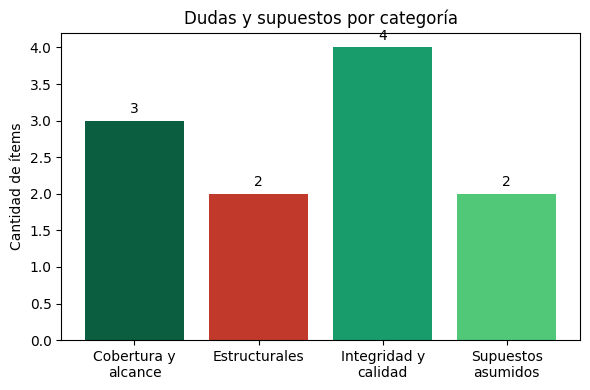

In [80]:
categorias = ["Cobertura y\nalcance", "Estructurales", "Integridad y\ncalidad", "Supuestos\nasumidos"]
conteos = [3, 2, 4, 2]

colores = ["#0b5e3f", "#c0392b", "#189c6b", "#50C878"]

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(categorias, conteos, color=colores)

ax.set_ylabel("Cantidad de ítems")
ax.set_title("Dudas y supuestos por categoría")

for barra, valor in zip(barras, conteos):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
             str(valor), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

*Nota: de las 11 dudas y supuestos identificados, la categoría de "Integridad y
calidad de datos" concentra la mayor cantidad de ítems (4), reflejando que la
mayoría de los vacíos de información identificados durante el entendimiento de
datos se relacionan con qué tan completos y confiables son los registros
compartidos por RaSA, más que con errores de diseño o alcance de las fuentes.*

## 8. Reflexión sobre el trabajo en equipo

De acuerdo con los criterios establecidos en la guía de la tarea, cada integrante del
equipo evaluó el desempeño de sus compañeros en una escala de 1 a 5, considerando los
siguientes criterios:

- **Cumplimiento:** cumplió con los compromisos definidos por el grupo en las fechas
  pactadas.
- **Calidad:** las actividades realizadas se hicieron con un buen nivel de calidad,
  aplicando lo visto en el curso, sin necesidad de rehacer o completar dichas partes.
- **Aporte:** aportó al desarrollo del proyecto dando pautas y buscando soluciones
  ante dificultades.
- **Comportamiento:** trató con respeto y amabilidad a los miembros del equipo,
  estuvo receptivo a sugerencias o críticas.

Tras socializar las evaluaciones individuales, el equipo llegó al siguiente consenso:

| Integrante | Cumplimiento | Calidad | Aporte | Comportamiento | Promedio |
|---|---|---|---|---|---|
| Nathalie Nicolle Bareño Naranjo | 5 | 5 | 5 | 5 | 5.0 |
| Erik Andrey Guerrero Velásquez | 5 | 5 | 5 | 5 | 5.0 |
| Christian Cantini Casas | 5 | 5 | 5 | 5 | 5.0 |
| Natalia Cantini Casas | 5 | 5 | 5 | 5 | 5.0 |

**Comentarios del equipo:**

El equipo mantuvo una dinámica de trabajo colaborativa, con cumplimiento oportuno de
los compromisos y buena disposición para resolver dudas conjuntamente durante el
desarrollo de la tarea.